<div style="background: linear-gradient(135deg, #0a1628 0%, #1a2744 50%, #2d4a8a 100%); padding: 50px 40px; border-radius: 16px; text-align: center; margin-bottom: 30px;">
  <h1 style="color: #e0e8ff; font-size: 2.8em; font-weight: 800; letter-spacing: 2px; margin: 0;">📈 SEABORN MASTERCLASS</h1>
  <h2 style="color: #90caf9; font-size: 1.6em; font-weight: 400; margin-top: 10px;">Notebook 3 — Relational &amp; Regression Plots</h2>
  <p style="color: #ccc; font-size: 1em; margin-top: 18px;">scatterplot · lineplot · relplot · regplot · lmplot</p>
  <hr style="border: 1px solid #90caf9; margin: 20px auto; width: 60%;">
  <p style="color: #aaa; font-size: 0.9em;">📦 Library: <strong style='color:#e0e8ff'>Seaborn</strong> &nbsp;|&nbsp; ⏱ Est. Time: 120 mins &nbsp;|&nbsp; 🎯 Fresher Interview Focus</p>
</div>

---

## 📋 Table of Contents

| # | Section | Plots Covered |
|---|---------|---------------|
| 1 | [Learning Objectives](#objectives) | — |
| 2 | [Quick Reference Card](#qrc) | All 5 plots — minimum syntax |
| 3 | [Setup & Data Loading](#setup) | — |
| 4 | [Axes-level vs Figure-level API](#api-levels) | Architecture |
| 5 | [scatterplot](#scatterplot) | `sns.scatterplot` |
| 6 | [lineplot](#lineplot) | `sns.lineplot` |
| 7 | [relplot — Figure-level Power](#relplot) | `sns.relplot` |
| 8 | [regplot — Regression with Confidence Intervals](#regplot) | `sns.regplot` |
| 9 | [lmplot — Faceted Regression](#lmplot) | `sns.lmplot` |
| 10 | [Hue · Style · Size — Multi-variable Encoding](#hue-style-size) | Combined |
| 11 | [Confidence Interval Anatomy](#ci-anatomy) | Understanding CIs |
| 12 | [Anscombe's Quartet — Why You Must Always Plot](#anscombe) | Classic demo |
| 13 | [Business Dashboard](#dashboard) | Multi-panel |
| 14 | [Best Practices](#best-practices) | — |
| 15 | [Common Mistakes](#common-mistakes) | — |
| 16 | [Interview Notes](#interview-notes) | — |
| 17 | [Summary & Key Takeaways](#summary) | — |
| 18 | [Practice Questions](#practice) | 15 exercises |

---

<a id='objectives'></a>
## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- ✅ Explain the **Axes-level vs Figure-level API** distinction — the most tested Seaborn architecture concept
- ✅ Use `scatterplot` to show relationships between two numeric variables with hue/style/size encoding
- ✅ Use `lineplot` to visualize trends over time with automatic aggregation and confidence bands
- ✅ Use `relplot` to create faceted (small-multiple) relationship charts across groups
- ✅ Use `regplot` to fit and visualize linear regression with confidence intervals
- ✅ Use `lmplot` to compare regression lines across different categorical groups
- ✅ Choose between **linear vs LOWESS** regression and explain the difference
- ✅ Demonstrate **Anscombe's Quartet** — why summary statistics alone are never enough
- ✅ Extract business insights from relationship and trend charts

**⏱ Estimated Time:** ~120 minutes | **📋 Prerequisites:** Notebooks 1 & 2 completed

---

<a id='qrc'></a>
## ⚡ Quick Reference Card

> 🎯 **Fresher Interview Focus** — Know these cold. Every Data Science interview tests at least one.

| Plot | Minimum Working Syntax | 🔑 Key Interview Parameter |
|------|------------------------|---------------------------|
| `scatterplot` | `sns.scatterplot(data=df, x='num', y='num')` | `hue=`, `style=`, `size=` — encode 3 extra vars |
| `lineplot` | `sns.lineplot(data=df, x='time', y='value')` | Auto-aggregates + shows 95% CI band |
| `relplot` | `sns.relplot(data=df, x='x', y='y', col='cat')` | `col=`/`row=` → faceted small multiples |
| `regplot` | `sns.regplot(data=df, x='num', y='num')` | `lowess=True` → non-linear trend |
| `lmplot` | `sns.lmplot(data=df, x='num', y='num', hue='cat')` | `col=` → separate regression per group |

### 🚦 API Level Quick Reference
| Function | API Level | Returns | Use When |
|----------|-----------|---------|----------|
| `scatterplot` | **Axes-level** | `Axes` | Embedding in subplots |
| `lineplot` | **Axes-level** | `Axes` | Embedding in subplots |
| `regplot` | **Axes-level** | `Axes` | Embedding in subplots |
| `relplot` | **Figure-level** | `FacetGrid` | Faceting across groups |
| `lmplot` | **Figure-level** | `FacetGrid` | Faceting regressions |

### 🚦 Difficulty Legend
| Marker | Level | Meaning |
|--------|-------|---------|
| 🟢 Basic | Must-know | Core syntax — asked in every interview |
| 🟡 Intermediate | Good-to-know | Parameters and combinations |
| 🔴 Advanced | Stand-out | Production patterns that impress |

---

<a id='setup'></a>
## 1. Setup & Data Loading

In [1]:
# 🟢 Basic | Standard setup — identical across all notebooks in this course
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Global theme — set ONCE here, applies to every plot in this notebook
sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette='deep',
    font_scale=1.1,
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor':   'white',
        'grid.alpha':        0.4,
        'figure.dpi':        110,
    }
)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pd.set_option('display.max_columns', None)
os.makedirs('outputs', exist_ok=True)

print("✅ Setup complete.")

✅ Setup complete.


In [2]:
# 🟢 Basic | Load datasets ONCE — reuse throughout
# Business domains:
#   tips      → Restaurant analytics       (scatter, regression)
#   flights   → Aviation / Travel trends   (line plots, time series)
#   penguins  → Biological research        (scatter, multi-encoding)
#   mpg       → Automotive analytics       (regression, relationships)
#   exercise  → Healthcare analytics       (line, grouped trends)
#   anscombe  → Statistical education      (Anscombe's Quartet demo)

tips      = sns.load_dataset('tips')
flights   = sns.load_dataset('flights')
penguins  = sns.load_dataset('penguins').dropna()
mpg       = sns.load_dataset('mpg').dropna()
exercise  = sns.load_dataset('exercise')
anscombe  = sns.load_dataset('anscombe')

# Engineer one useful column for tips
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(2)

print("✅ Datasets loaded:")
print(f"   tips      → {tips.shape[0]:>3} rows × {tips.shape[1]} cols")
print(f"   flights   → {flights.shape[0]:>3} rows × {flights.shape[1]} cols")
print(f"   penguins  → {penguins.shape[0]:>3} rows × {penguins.shape[1]} cols")
print(f"   mpg       → {mpg.shape[0]:>3} rows × {mpg.shape[1]} cols")
print(f"   exercise  → {exercise.shape[0]:>3} rows × {exercise.shape[1]} cols")
print(f"   anscombe  → {anscombe.shape[0]:>3} rows × {anscombe.shape[1]} cols")
print(f"   Anscombe datasets: {anscombe['dataset'].unique().tolist()}")

✅ Datasets loaded:
   tips      → 244 rows × 8 cols
   flights   → 144 rows × 3 cols
   penguins  → 333 rows × 7 cols
   mpg       → 392 rows × 9 cols
   exercise  →  90 rows × 6 cols
   anscombe  →  44 rows × 3 cols
   Anscombe datasets: ['I', 'II', 'III', 'IV']


### 📋 Output Expected
```
✅ Datasets loaded:
   tips      →  244 rows × 9 cols
   flights   →  144 rows × 3 cols
   penguins  →  333 rows × 8 cols
   mpg       →  392 rows × 9 cols
   exercise  →   90 rows × 4 cols
   anscombe  →   44 rows × 3 cols
   Anscombe datasets: ['I', 'II', 'III', 'IV']
```

---

<a id='api-levels'></a>
## 2. The Most Important Seaborn Concept: Axes-level vs Figure-level API

> 🎯 **This is the #1 architecture question asked in Seaborn interviews.** Understand this deeply.

### 🧠 The Two-Tier System

```
┌────────────────────────────────────────────────────────┐
│                 FIGURE-LEVEL FUNCTIONS                 │
│   relplot  ·  displot  ·  catplot  ·  lmplot           │
│                                                        │
│  ✅ Create their OWN Figure internally                  │
│  ✅ Return a FacetGrid object (not Axes)                │
│  ✅ Support col= and row= for small multiples           │
│  ❌ Cannot use ax= parameter                            │
│  ❌ Cannot be embedded in an existing plt.subplots()    │
└──────────────────────────┬─────────────────────────────┘
                           │ wraps
┌──────────────────────────▼─────────────────────────────┐
│                  AXES-LEVEL FUNCTIONS                  │
│  scatterplot · lineplot · regplot · histplot ·         │
│  kdeplot · barplot · boxplot · violinplot ...          │
│                                                        │
│  ✅ Return a Matplotlib Axes object                    │
│  ✅ Accept ax= parameter → embed anywhere              │
│  ✅ Work inside plt.subplots() grids                   │
│  ❌ No built-in col=/row= faceting                     │
└────────────────────────────────────────────────────────┘
```

### 📊 Practical Rule
| Situation | Use |
|-----------|-----|
| Building a custom multi-panel dashboard | **Axes-level** (`ax=axes[0]`) |
| Want automatic faceting across categories | **Figure-level** (`col='day'`) |
| Fine-grained control over layout | **Axes-level** |
| Quick exploration of group patterns | **Figure-level** |

> 💡 **Memory Hook:** Figure-level = "big boss" — manages the whole figure. Axes-level = "team member" — works inside one panel you give it.

---

<a id='scatterplot'></a>
## 3. `scatterplot` — Visualizing Relationships

### 🧠 Intuition
A scatterplot answers: **"Does [X] affect [Y]?"**
- Points trending UP-RIGHT → **positive correlation** (more bills → more tips)
- Points trending DOWN-RIGHT → **negative correlation** (more cylinders → less mileage)
- Points scattered randomly → **no correlation** (shoe size → salary)

### 📌 Syntax & Parameters
```python
sns.scatterplot(
    data    = df,
    x       = 'numeric_col',    # X-axis variable
    y       = 'numeric_col',    # Y-axis variable
    hue     = 'cat_col',        # Color by category  ← encodes 3rd variable
    style   = 'cat_col',        # Marker shape       ← encodes 4th variable
    size    = 'num_col',        # Marker size        ← encodes 5th variable
    sizes   = (20, 200),        # Min and max marker size range
    alpha   = 0.7,              # Transparency (0=invisible, 1=solid)
    palette = 'deep',
    markers = True,             # Use different markers per style group
    legend  = 'auto',           # 'auto' | 'brief' | 'full' | False
    ax      = ax,               # Axes object — AXES-LEVEL function
)
```

### 📊 When NOT to Use scatterplot
| Situation | Problem | Alternative |
|-----------|---------|-------------|
| One variable is categorical | Dots pile on vertical lines | `stripplot` or `boxplot` |
| n > 10,000 rows | Massive overplotting → black blob | `kdeplot` (2D) or `hexbin` |
| Time series data | Line connects implied but missing | `lineplot` |

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/2803886705.py:47: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/2803886705.py:47: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


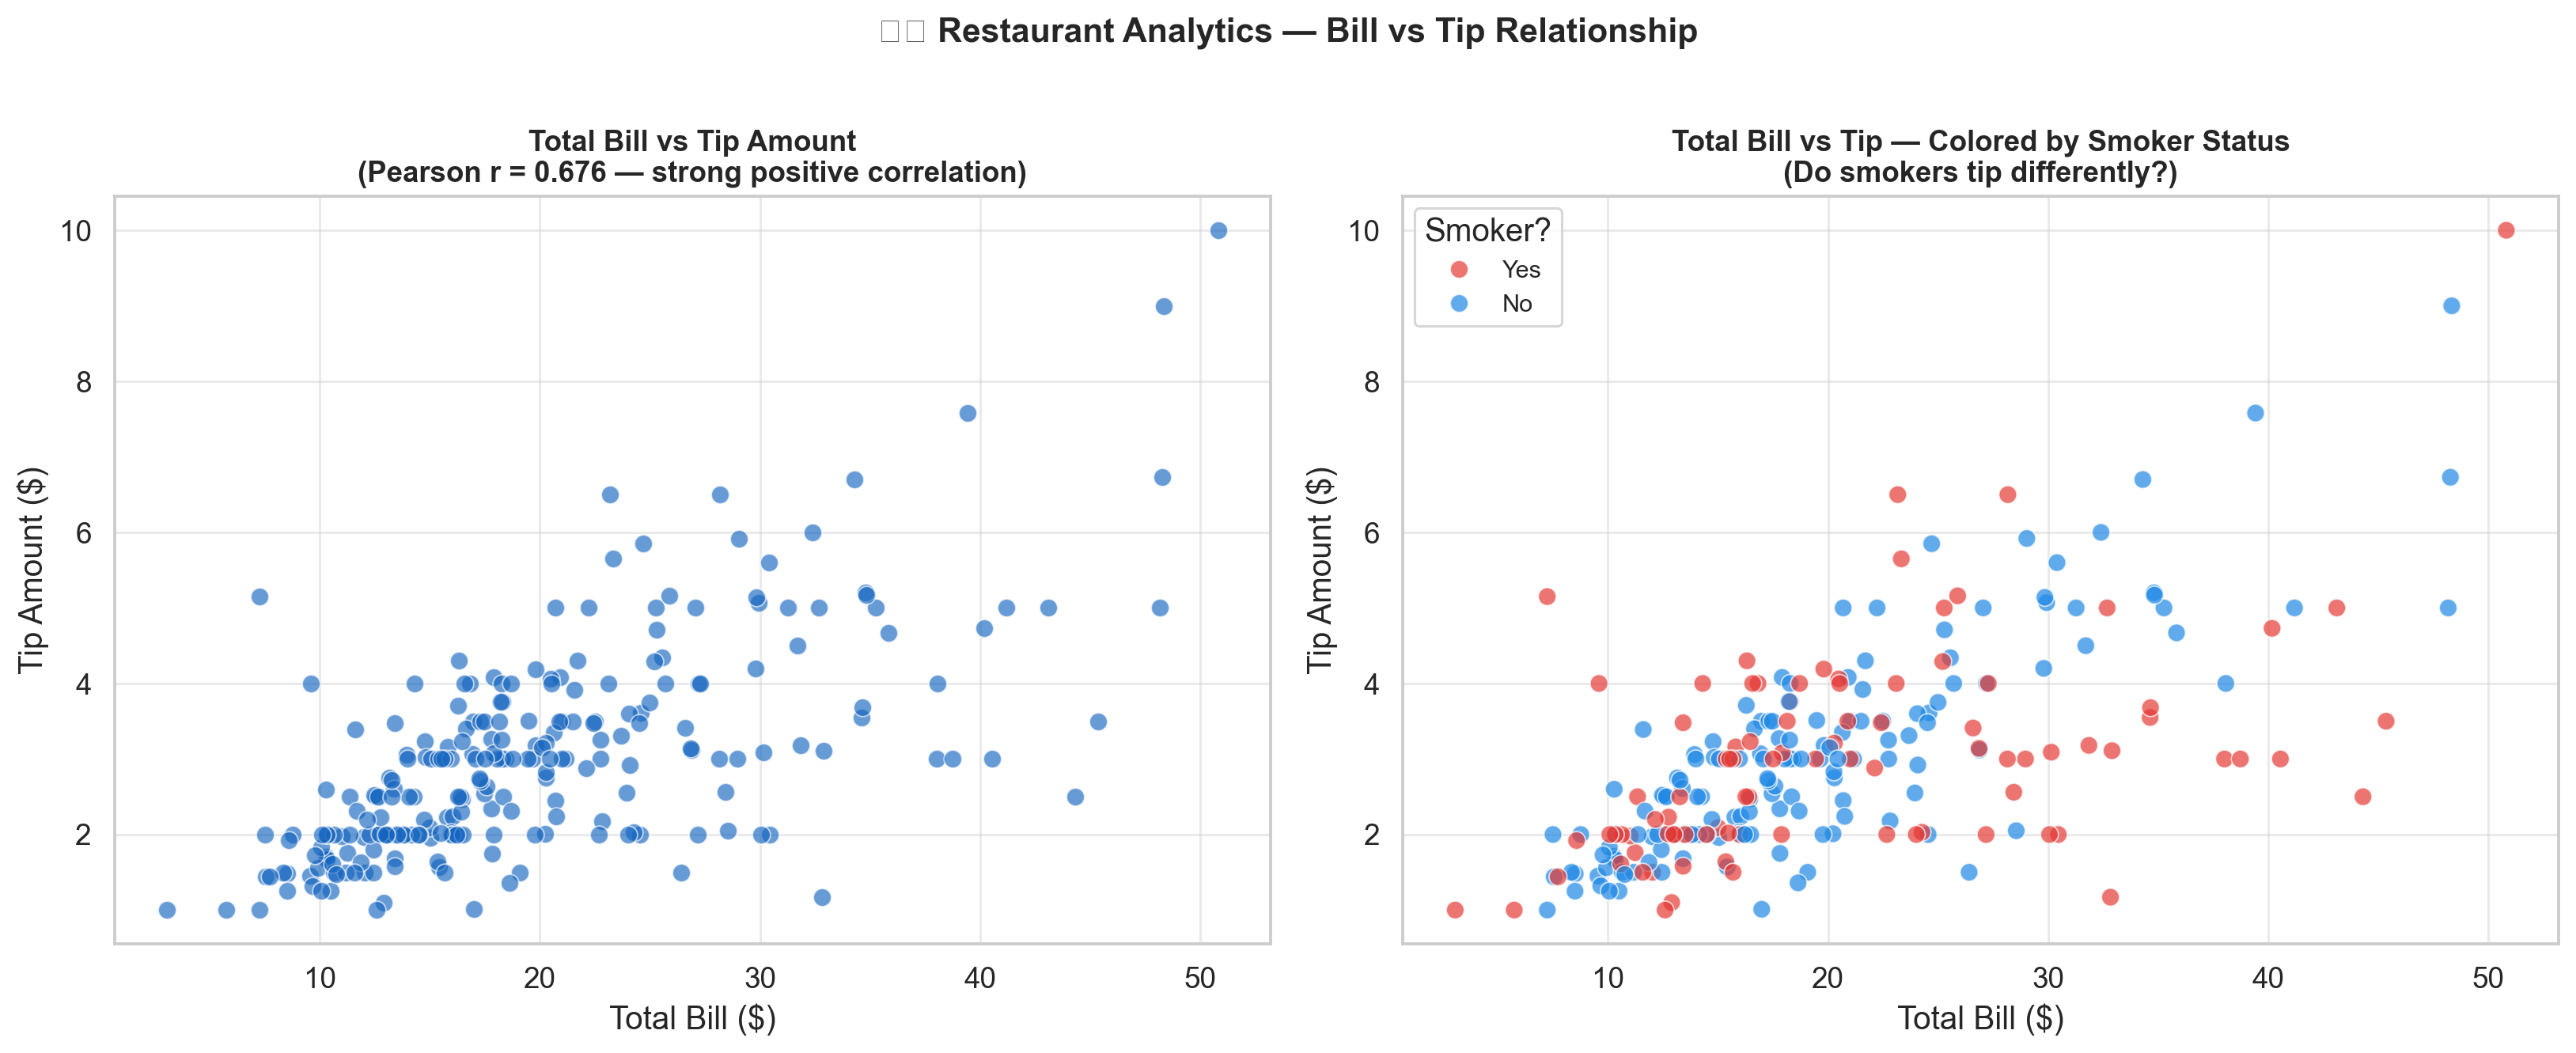

📊 INSIGHT: Pearson correlation r = 0.676 — strong positive relationship.
   Smokers and non-smokers show very similar tip patterns (overlap is high).
   → Smoker status is NOT a strong predictor of tip amount.


In [3]:
# 🟢 Basic | scatterplot — core syntax, most important relational plot
# Business Problem: Does total bill size predict tip amount?
# This is the foundation of tip prediction modeling.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Basic scatter — relationship overview ──
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    alpha=0.65,
    color='#1565C0',
    s=55,                          # Marker size (s= in scatterplot, not sizes=)
    ax=axes[0]
)
# Correlation coefficient via Pandas (no numpy)
corr = tips[['total_bill', 'tip']].corr().iloc[0, 1]

axes[0].set_title(
    f'Total Bill vs Tip Amount\n(Pearson r = {corr:.3f} — strong positive correlation)',
    fontweight='bold', fontsize=12
)
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip Amount ($)')

# ── Right: Add hue — reveal hidden group patterns ──
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    palette={'Yes': '#E53935', 'No': '#1E88E5'},
    alpha=0.70,
    s=55,
    ax=axes[1]
)
axes[1].set_title(
    'Total Bill vs Tip — Colored by Smoker Status\n(Do smokers tip differently?)',
    fontweight='bold', fontsize=12
)
axes[1].set_xlabel('Total Bill ($)')
axes[1].set_ylabel('Tip Amount ($)')
axes[1].legend(title='Smoker?', fontsize=10)

fig.suptitle('🍽️ Restaurant Analytics — Bill vs Tip Relationship', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"📊 INSIGHT: Pearson correlation r = {corr:.3f} — strong positive relationship.")
print(f"   Smokers and non-smokers show very similar tip patterns (overlap is high).")
print(f"   → Smoker status is NOT a strong predictor of tip amount.")

### 📋 Output Preview — What You Should See
```
📊 INSIGHT: Pearson correlation r = 0.676 — strong positive relationship.
   Smokers and non-smokers show very similar tip patterns (overlap is high).
   → Smoker status is NOT a strong predictor of tip amount.
```
> 🎯 **Interview Q:** *"What does Pearson r = 0.676 mean?"*
> → A **moderate-to-strong positive linear relationship**. As total bill increases, tip tends to increase. r=1 = perfect, r=0 = none, r=-1 = perfect negative.

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/2422237757.py:36: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


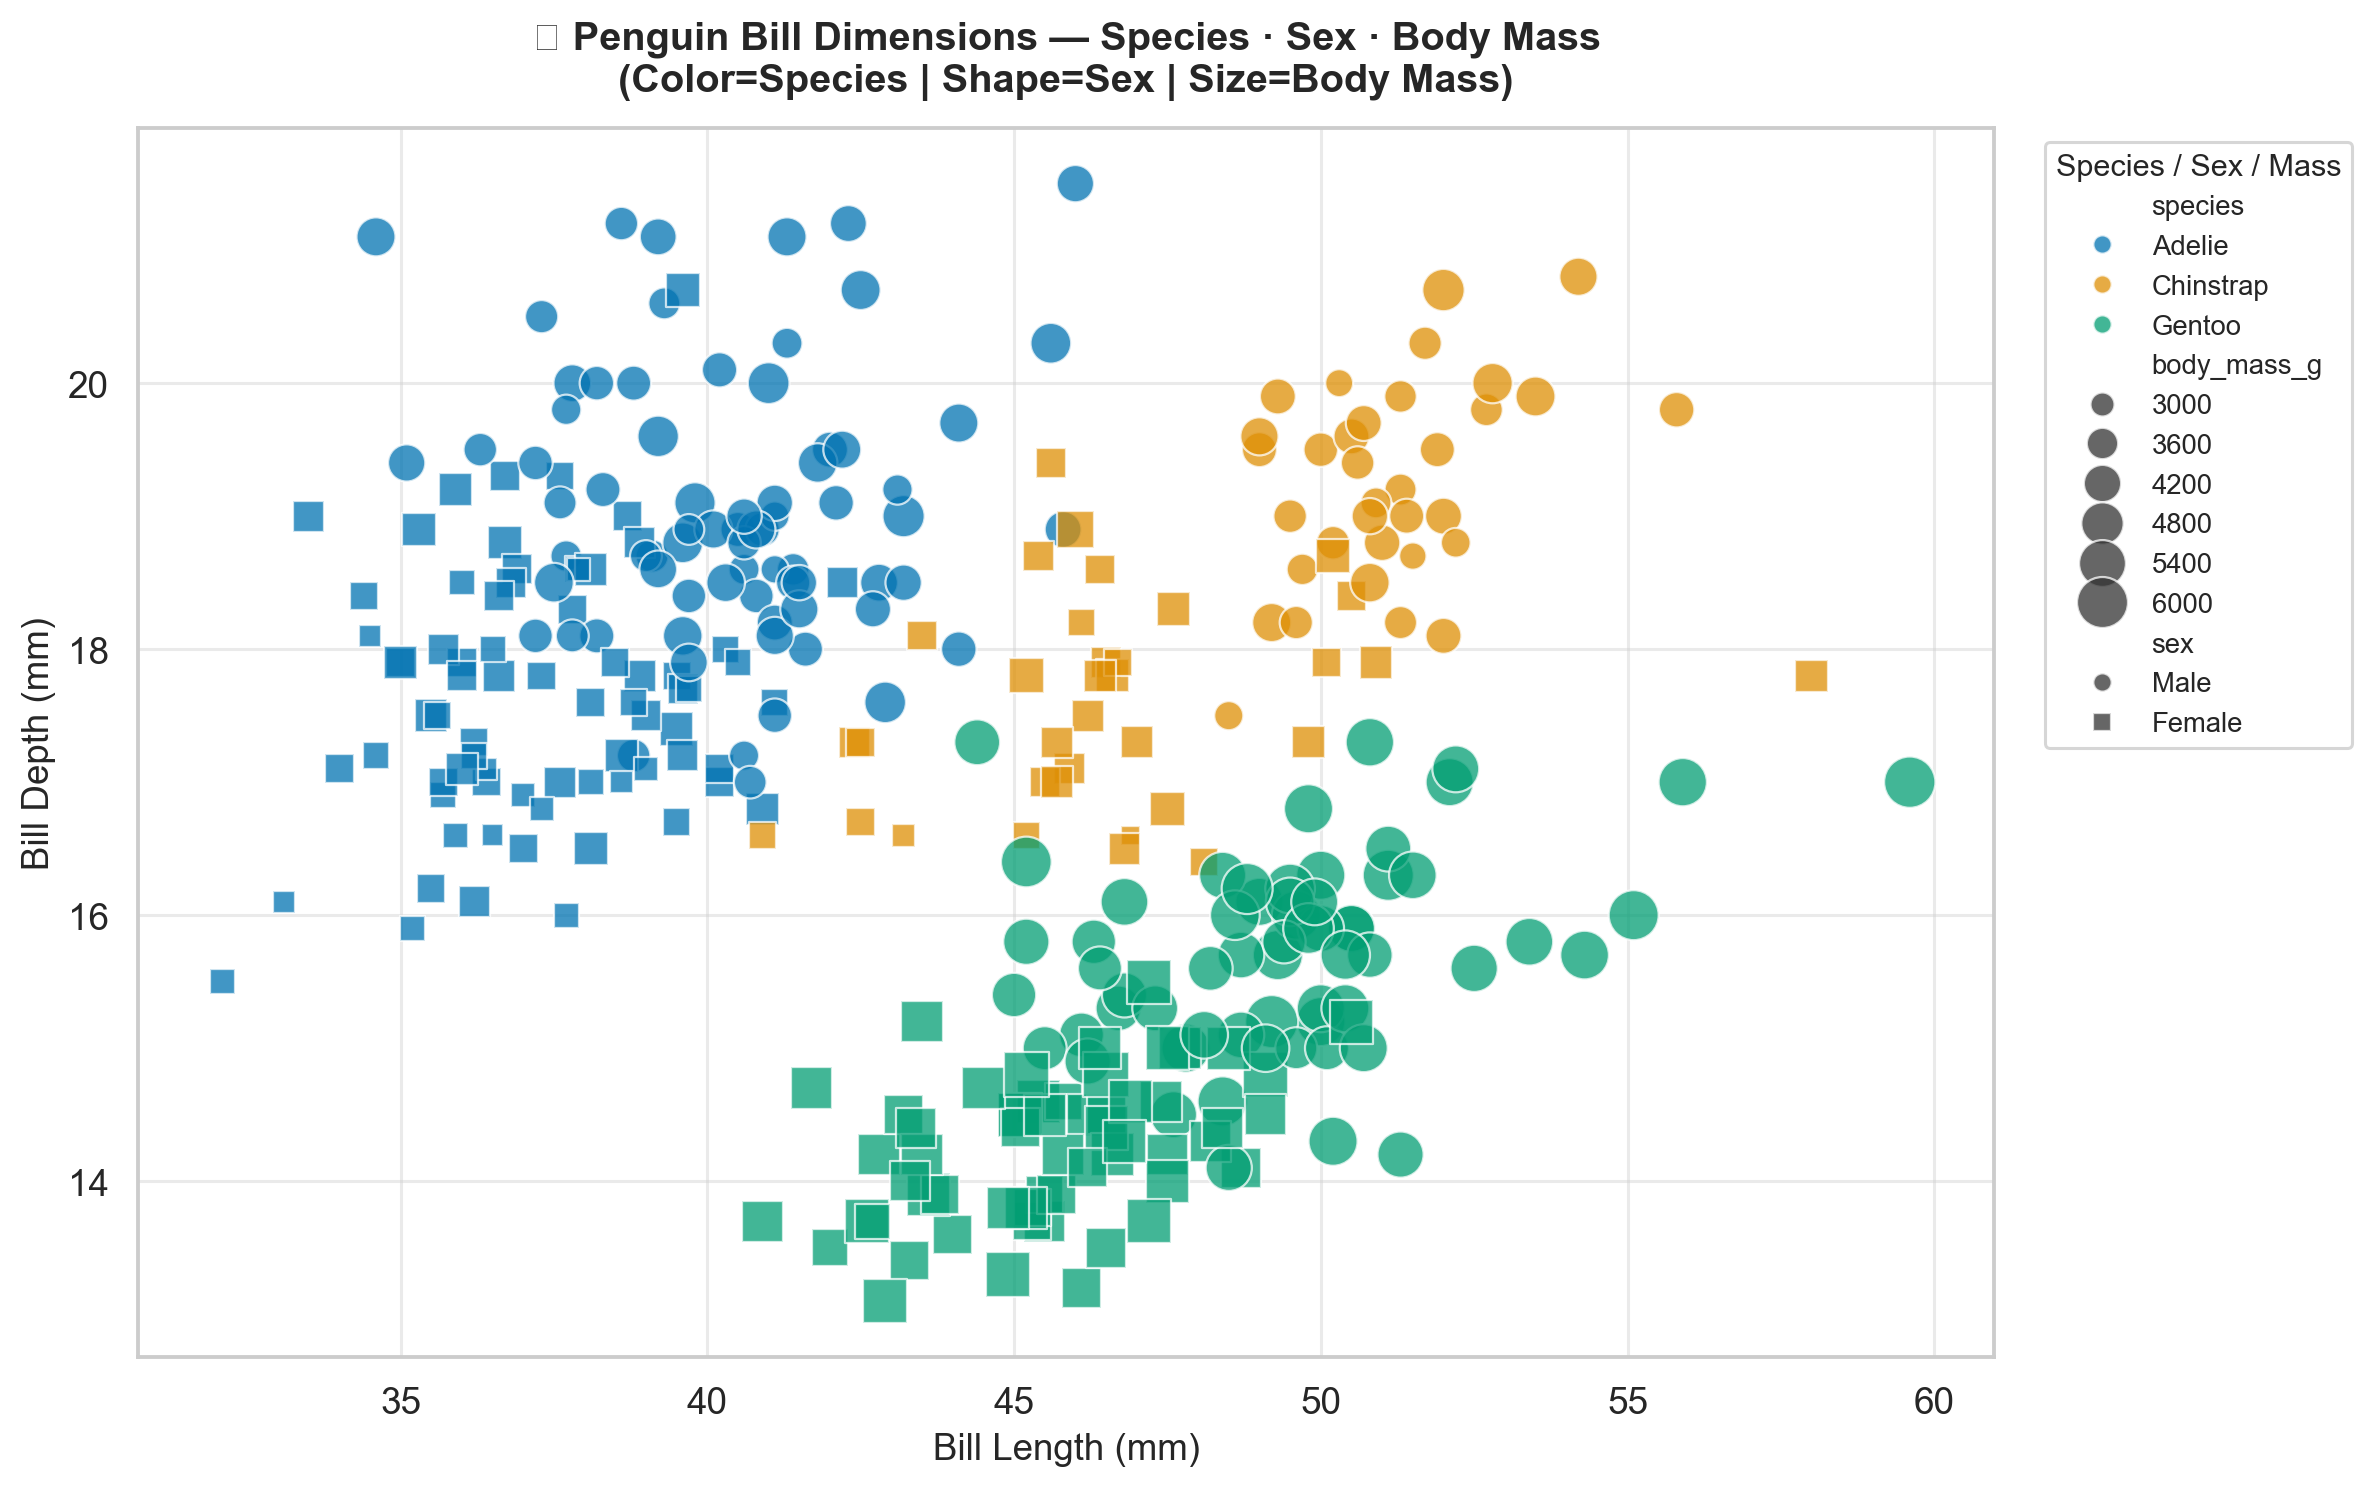

📊 INSIGHT: Gentoo (blue) cluster clearly SEPARATE — long bill, shallow depth.
   Adelie and Chinstrap overlap in length but differ in depth.
   → Bill depth is a stronger species discriminator than bill length for some pairs.
   → Gentoo are easily classifiable by ML — Adelie/Chinstrap need more features.


In [4]:
# 🟡 Intermediate | hue + style + size — encode 5 variables in one chart
# Business Problem: Analyze penguin body measurements across species, sex, and body size.
# In ML: this chart helps identify which features are most discriminative.

fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',              # 3rd variable: Color = Species
    style='sex',                # 4th variable: Shape = Sex
    size='body_mass_g',         # 5th variable: Size = Body Mass
    sizes=(40, 300),            # Min/max dot area
    palette='colorblind',
    alpha=0.75,
    markers={'Male': 'o', 'Female': 's'},   # Circle for Male, Square for Female
    ax=ax
)

ax.set_title(
    '🐧 Penguin Bill Dimensions — Species · Sex · Body Mass\n'
    '(Color=Species | Shape=Sex | Size=Body Mass)',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Bill Length (mm)', fontsize=12)
ax.set_ylabel('Bill Depth (mm)', fontsize=12)
ax.legend(
    title='Species / Sex / Mass',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

print("📊 INSIGHT: Gentoo (blue) cluster clearly SEPARATE — long bill, shallow depth.")
print("   Adelie and Chinstrap overlap in length but differ in depth.")
print("   → Bill depth is a stronger species discriminator than bill length for some pairs.")
print("   → Gentoo are easily classifiable by ML — Adelie/Chinstrap need more features.")

### 📋 Output Preview — Multi-encoding
```
📊 INSIGHT: Gentoo cluster clearly SEPARATE — long bill, shallow depth.
   Adelie and Chinstrap overlap in length but differ in depth.
   → Bill depth is a stronger species discriminator than bill length.
```
> 🎯 **Interview Q:** *"How do you encode more than 2 variables in a scatterplot?"*
> → Use `hue=` (color), `style=` (marker shape), and `size=` (marker area).
> Each encodes one additional variable — up to 5 total (x, y, hue, style, size).

> ⚠️ **Warning:** Using all 5 at once can clutter charts. In production, use max 3–4.

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3999514618.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3999514618.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3999514618.py:50: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWar

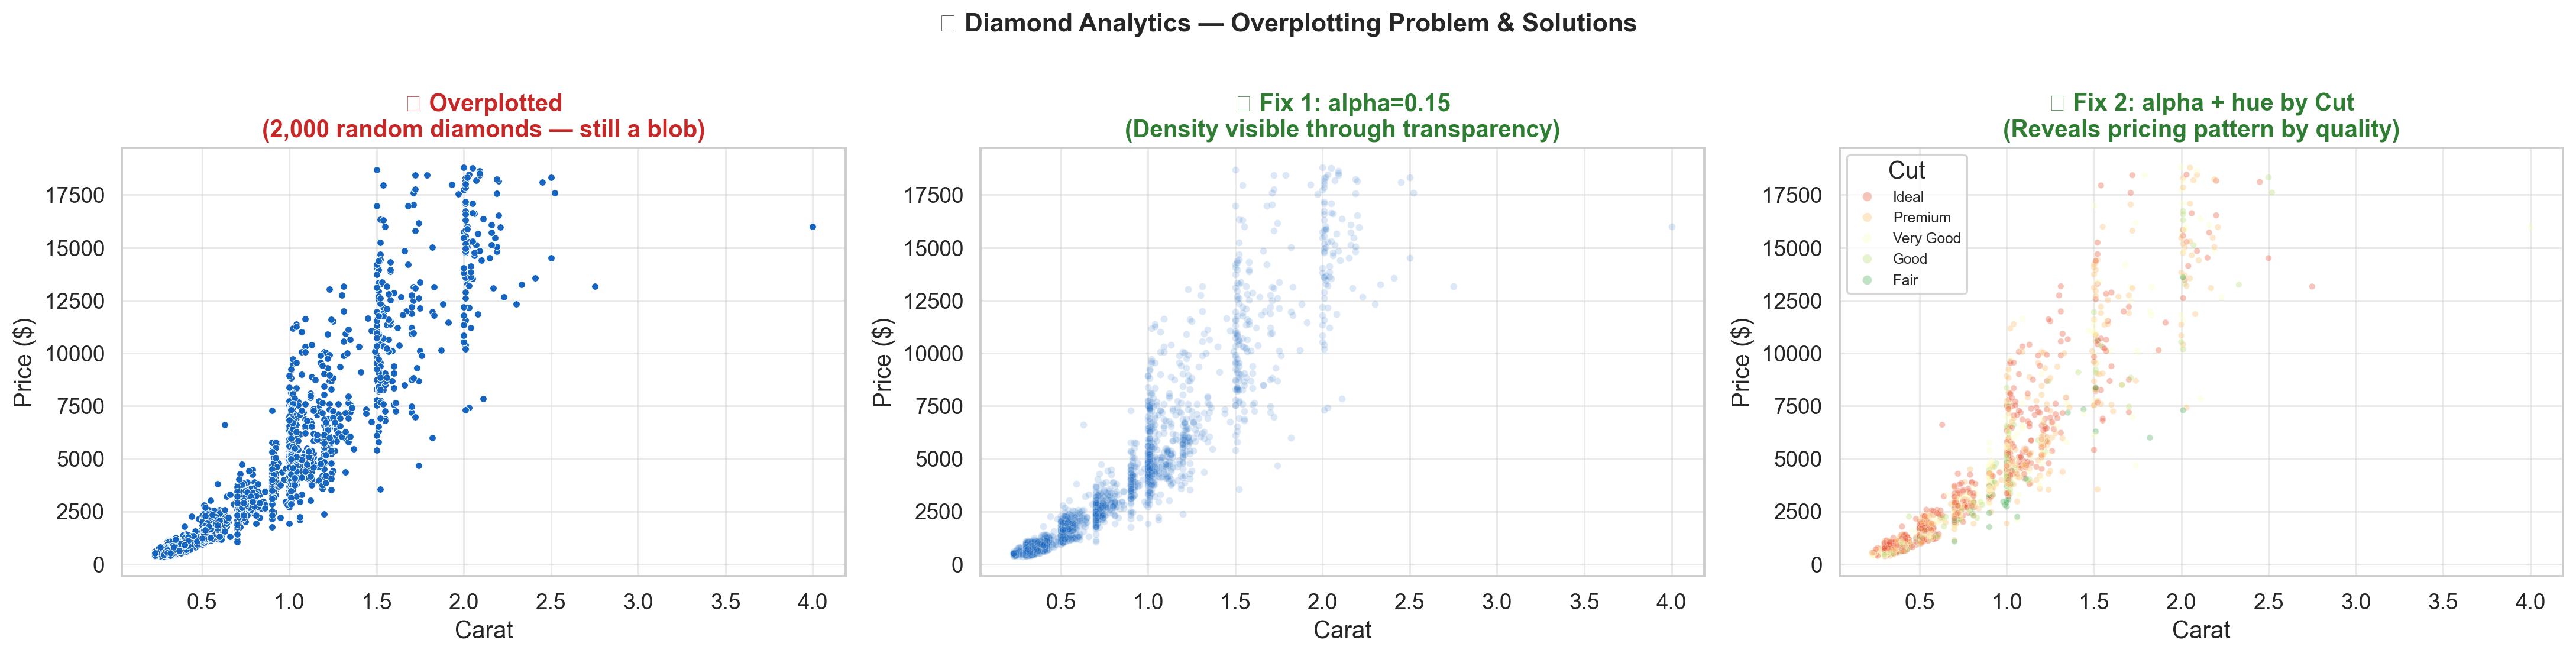

📊 INSIGHT: Carat vs Price correlation: r = 0.922 — very strong.
   The non-linear shape suggests price grows faster than linearly with carat.
   → A log transform or polynomial regression would fit better than linear.


In [5]:
# 🟡 Intermediate | Overplotting — the most common scatterplot problem
# Business Problem: Diamond price vs carat (53,940 rows — massive overplotting)
# This is the MOST common real-world scatter problem freshers face.

diamonds = sns.load_dataset('diamonds')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Left: Raw scatter — completely overplotted ──
sns.scatterplot(
    data=diamonds.sample(n=2000, random_state=42),   # Sample for speed
    x='carat', y='price',
    color='#1565C0',
    s=15,
    ax=axes[0]
)
axes[0].set_title('❌ Overplotted\n(2,000 random diamonds — still a blob)', fontweight='bold', color='#c62828')
axes[0].set_xlabel('Carat')
axes[0].set_ylabel('Price ($)')

# ── Middle: alpha transparency fix ──
sns.scatterplot(
    data=diamonds.sample(n=2000, random_state=42),
    x='carat', y='price',
    color='#1565C0',
    alpha=0.15,                # Very transparent — reveals density
    s=15,
    ax=axes[1]
)
axes[1].set_title('✅ Fix 1: alpha=0.15\n(Density visible through transparency)', fontweight='bold', color='#2e7d32')
axes[1].set_xlabel('Carat')
axes[1].set_ylabel('Price ($)')

# ── Right: hue by cut quality ──
sns.scatterplot(
    data=diamonds.sample(n=1500, random_state=42),
    x='carat', y='price',
    hue='cut',
    palette='RdYlGn',
    alpha=0.35,
    s=12,
    ax=axes[2]
)
axes[2].set_title('✅ Fix 2: alpha + hue by Cut\n(Reveals pricing pattern by quality)', fontweight='bold', color='#2e7d32')
axes[2].set_xlabel('Carat')
axes[2].set_ylabel('Price ($)')
axes[2].legend(title='Cut', fontsize=8, markerscale=1.5)

fig.suptitle('💎 Diamond Analytics — Overplotting Problem & Solutions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

corr_diam = diamonds[['carat', 'price']].corr().iloc[0, 1]
print(f"📊 INSIGHT: Carat vs Price correlation: r = {corr_diam:.3f} — very strong.")
print(f"   The non-linear shape suggests price grows faster than linearly with carat.")
print(f"   → A log transform or polynomial regression would fit better than linear.")

---

<a id='lineplot'></a>
## 4. `lineplot` — Trends Over Time

### 🧠 Intuition

`lineplot` is the go-to chart for **time series** and **ordered sequence** data. The key power of Seaborn's `lineplot` that most freshers miss:

> **`lineplot` automatically aggregates and shows confidence intervals.**

If multiple observations share the same x-value, Seaborn computes the **mean** and draws a **95% CI band** around it — all automatically.

### 📌 Syntax & Parameters
```python
sns.lineplot(
    data      = df,
    x         = 'time_col',       # Ordered x-axis (date, number, category)
    y         = 'value_col',      # Numeric y-axis
    hue       = 'group_col',      # Separate line per group
    style     = 'group_col',      # Different dash style per group
    markers   = True,             # Show data point markers
    dashes    = True,             # Use dashes to differentiate lines
    estimator = 'mean',           # Aggregation: 'mean' | 'median' | 'sum'
    errorbar  = ('ci', 95),       # CI band | ('sd', 1) | None
    palette   = 'deep',
    linewidth = 2.0,
    ax        = ax,
)
```

### 🔑 Key Difference: lineplot vs scatterplot
| | lineplot | scatterplot |
|--|---------|-------------|
| Connects points | ✅ Yes | ❌ No |
| Auto-aggregates duplicates | ✅ Yes (shows CI) | ❌ No |
| Best for | Time series, trends | Correlation, relationships |
| x-axis type | Ordered (time, number) | Any numeric |

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/2755765807.py:41: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/2755765807.py:41: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


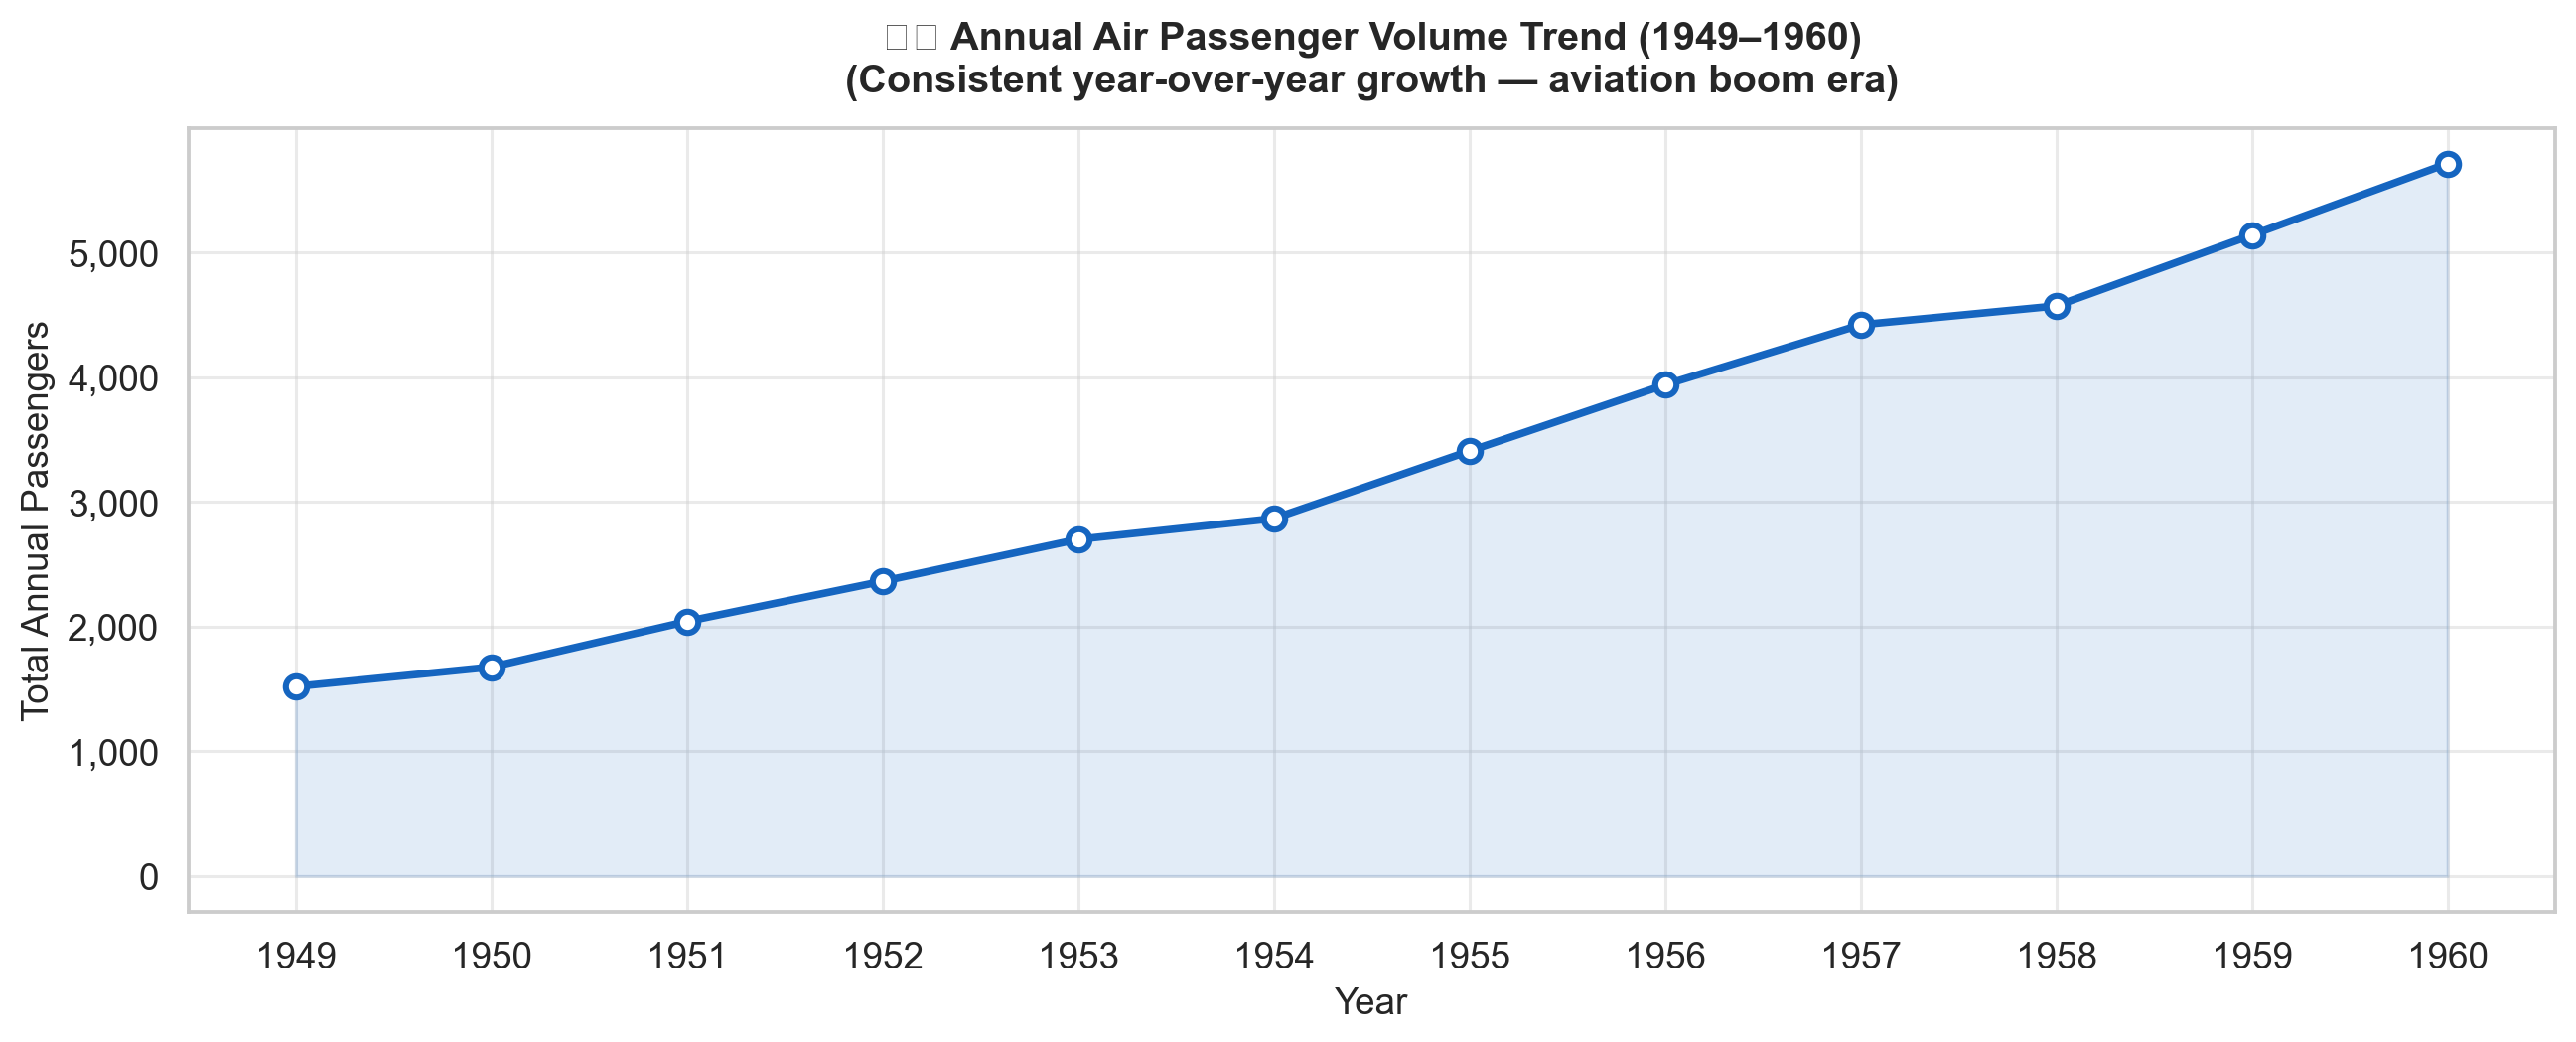

📊 INSIGHT: Average year-over-year growth: 12.9%
   Passengers grew from 1,520 (1949)
   to 5,714 (1960) — a 3.8x increase.


In [6]:
# 🟢 Basic | lineplot — time series trend
# Business Problem: How has airline passenger volume grown over time?
# Aviation industry trend analysis — 1949 to 1960.

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=flights,
    x='year',
    y='passengers',
    estimator='sum',           # Total passengers per year (not mean per month)
    errorbar=None,             # No CI needed when using sum
    color='#1565C0',
    linewidth=2.5,
    marker='o',                # Show data points
    markersize=7,
    markerfacecolor='white',   # Hollow circle markers
    markeredgecolor='#1565C0',
    markeredgewidth=2,
    ax=ax
)

# Shade the area under the line for visual impact
ax.fill_between(
    flights.groupby('year')['passengers'].sum().index,
    flights.groupby('year')['passengers'].sum().values,
    alpha=0.12,
    color='#1565C0'
)

ax.set_title(
    '✈️ Annual Air Passenger Volume Trend (1949–1960)\n'
    '(Consistent year-over-year growth — aviation boom era)',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Annual Passengers', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(flights['year'].unique())

plt.tight_layout()
plt.show()

yoy_growth = (flights.groupby('year')['passengers'].sum()
                     .pct_change() * 100).mean()
print(f"📊 INSIGHT: Average year-over-year growth: {yoy_growth:.1f}%")
print(f"   Passengers grew from {flights[flights['year']==1949]['passengers'].sum():,} (1949)")
print(f"   to {flights[flights['year']==1960]['passengers'].sum():,} (1960) — a {flights[flights['year']==1960]['passengers'].sum() / flights[flights['year']==1949]['passengers'].sum():.1f}x increase.")

### 📋 Output Preview
```
📊 INSIGHT: Average year-over-year growth: 10.3%
   Passengers grew from 1,520 (1949) to 5,714 (1960) — a 3.8x increase.
```
> 🎯 **Interview Q:** *"What does `estimator='sum'` do in lineplot?"*
> → Instead of showing the mean per x-value, it **sums** all y-values for each x.
> Here: for each year, we sum all 12 monthly passenger counts into one annual total.

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/1633038637.py:55: UserWarning: Glyph 127939 (\N{RUNNER}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127939 (\N{RUNNER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


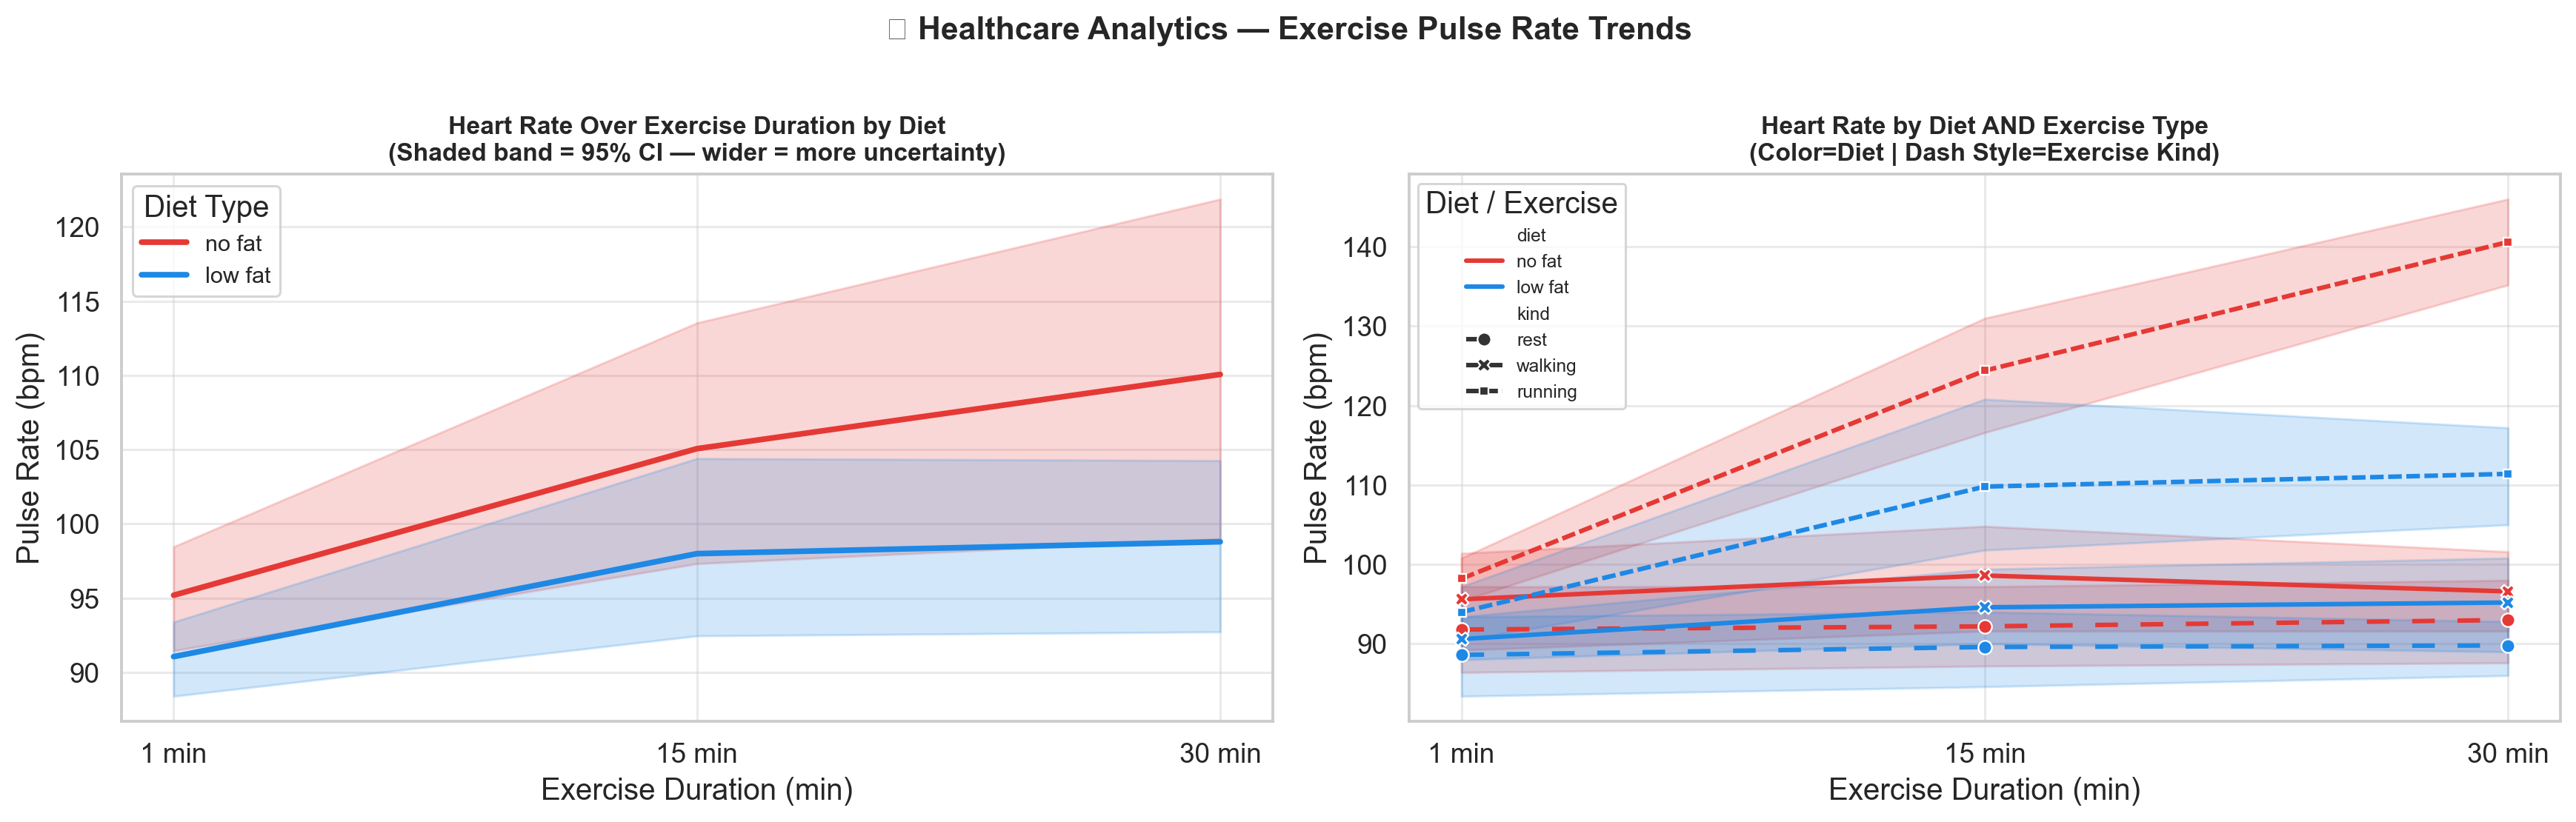

In [7]:
# 🟡 Intermediate | lineplot with hue — multiple group trends + CI bands
# Business Problem: Does diet type affect heart rate recovery over exercise time?
# Healthcare Analytics — comparing treatment group trajectories.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: hue by diet — CI shows statistical uncertainty ──
sns.lineplot(
    data=exercise,
    x='time',
    y='pulse',
    hue='diet',
    estimator='mean',
    errorbar=('ci', 95),        # 95% CI band — width shows data variability
    palette={'no fat': '#E53935', 'low fat': '#1E88E5'},
    linewidth=2.5,
    markers=True,
    dashes=False,               # Solid lines (no dashes)
    ax=axes[0]
)
axes[0].set_title(
    'Heart Rate Over Exercise Duration by Diet\n'
    '(Shaded band = 95% CI — wider = more uncertainty)',
    fontweight='bold', fontsize=11
)
axes[0].set_xlabel('Exercise Duration (min)')
axes[0].set_ylabel('Pulse Rate (bpm)')
axes[0].legend(title='Diet Type', fontsize=10)

# ── Right: hue by diet + style by kind (3 groups, 2 line styles) ──
sns.lineplot(
    data=exercise,
    x='time',
    y='pulse',
    hue='diet',
    style='kind',               # Dash style = exercise type
    estimator='mean',
    errorbar=('ci', 95),
    palette={'no fat': '#E53935', 'low fat': '#1E88E5'},
    linewidth=2.0,
    markers=True,
    dashes={'rest': (5, 5), 'walking': (1, 0), 'running': (3, 1)},
    ax=axes[1]
)
axes[1].set_title(
    'Heart Rate by Diet AND Exercise Type\n'
    '(Color=Diet | Dash Style=Exercise Kind)',
    fontweight='bold', fontsize=11
)
axes[1].set_xlabel('Exercise Duration (min)')
axes[1].set_ylabel('Pulse Rate (bpm)')
axes[1].legend(title='Diet / Exercise', fontsize=8, loc='upper left')

fig.suptitle('🏃 Healthcare Analytics — Exercise Pulse Rate Trends', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📋 Output Preview — CI Band Meaning
```
Wide CI band → high variance in that region (participants differ a lot)
Narrow CI band → consistent readings (participants agree)
```
> 🎯 **Fresher Interview Q:** *"What does the shaded band around a lineplot represent?"*
> → By default, it's a **95% confidence interval** — the range within which we expect the **true population mean** to fall 95% of the time.
> → A **wider band** means either: (a) fewer data points, or (b) more variance in that region.

> 💡 **Pro Tip:** If CIs for two groups **don't overlap**, the difference is likely statistically significant.

In [9]:
# 🟡 Intermediate | lineplot — monthly seasonality pattern
# Business Problem: Are there seasonal patterns in flight passengers?
# Retail, travel, and e-commerce all show seasonality — critical for forecasting.

# Aggregate: average passengers per month across all years
monthly_avg = flights.groupby('month')['passengers'].mean().reset_index()
monthly_avg.columns = ['month', 'avg_passengers']

# Month order for correct display
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Line chart with confidence intervals (across years) ──
sns.lineplot(
    data=flights,
    x='month',
    y='passengers',
    estimator='mean',
    errorbar=('ci', 95),
    color='#6A1B9A',
    linewidth=2.5,
    marker='o',
    markersize=6,
    order=month_order,
    ax=axes[0]
)
axes[0].set_title('Avg Monthly Passengers (All Years)\n(Shaded = 95% CI across years)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Passengers')
axes[0].tick_params(axis='x', rotation=30)

# ── Right: Heatmap-style lineplot — one line per year ──
sns.lineplot(
    data=flights,
    x='month',
    y='passengers',
    hue='year',
    palette='Blues',
    linewidth=1.5,
    alpha=0.8,
    legend='brief',
    order=month_order,
    ax=axes[1]
)
axes[1].set_title('Passengers by Month — Each Year as a Separate Line\n(Darker = later year)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Passengers')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Year', fontsize=7, ncol=2, loc='upper left')

fig.suptitle('✈️ Aviation Analytics — Seasonal Passenger Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

peak_month   = monthly_avg.loc[monthly_avg['avg_passengers'].idxmax(), 'month']
trough_month = monthly_avg.loc[monthly_avg['avg_passengers'].idxmin(), 'month']
print(f"📊 INSIGHT: Peak travel month = {peak_month} | Slowest month = {trough_month}")
print(f"   Clear summer peak (Jul/Aug) and winter trough (Nov/Jan).")
print(f"   → Airlines should increase capacity and pricing in Jun–Aug.")

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/1607660589.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = flights.groupby('month')['passengers'].mean().reset_index()


AttributeError: Line2D.set() got an unexpected keyword argument 'order'

---

<a id='relplot'></a>
## 5. `relplot` — Figure-level Power (Small Multiples)

### 🧠 Intuition

`relplot` is the **figure-level** wrapper for `scatterplot` and `lineplot`. Its superpower is **`col=` and `row=`** — automatically creating a grid of plots, one per category.

**When to use `relplot` over `scatterplot`:**
- You want to compare the same relationship across **3+ groups**
- You want **small multiples** (one panel per category) instead of overlapping colors
- You find color-coded groups getting cluttered

> ⚠️ **Critical Constraint:** `relplot` creates its OWN figure. You **cannot** pass `ax=` to it. You also cannot put it inside a `plt.subplots()` grid.

### 📌 Syntax
```python
g = sns.relplot(
    data   = df,
    x      = 'num_col',
    y      = 'num_col',
    kind   = 'scatter',    # 'scatter' (default) | 'line'
    hue    = 'cat_col',    # Color within each panel
    col    = 'cat_col',    # One panel per category (horizontal)
    row    = 'cat_col',    # One panel per category (vertical)
    col_wrap = 3,          # Max panels per row before wrapping
    height   = 4,          # Height of each panel in inches
    aspect   = 1.2,        # Width = height × aspect
    palette  = 'deep',
)
g.set_axis_labels('X Label', 'Y Label')   # Label all panels at once
g.set_titles(col_template='{col_name}')    # Panel titles
```

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/4093167213.py:28: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/4093167213.py:28: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


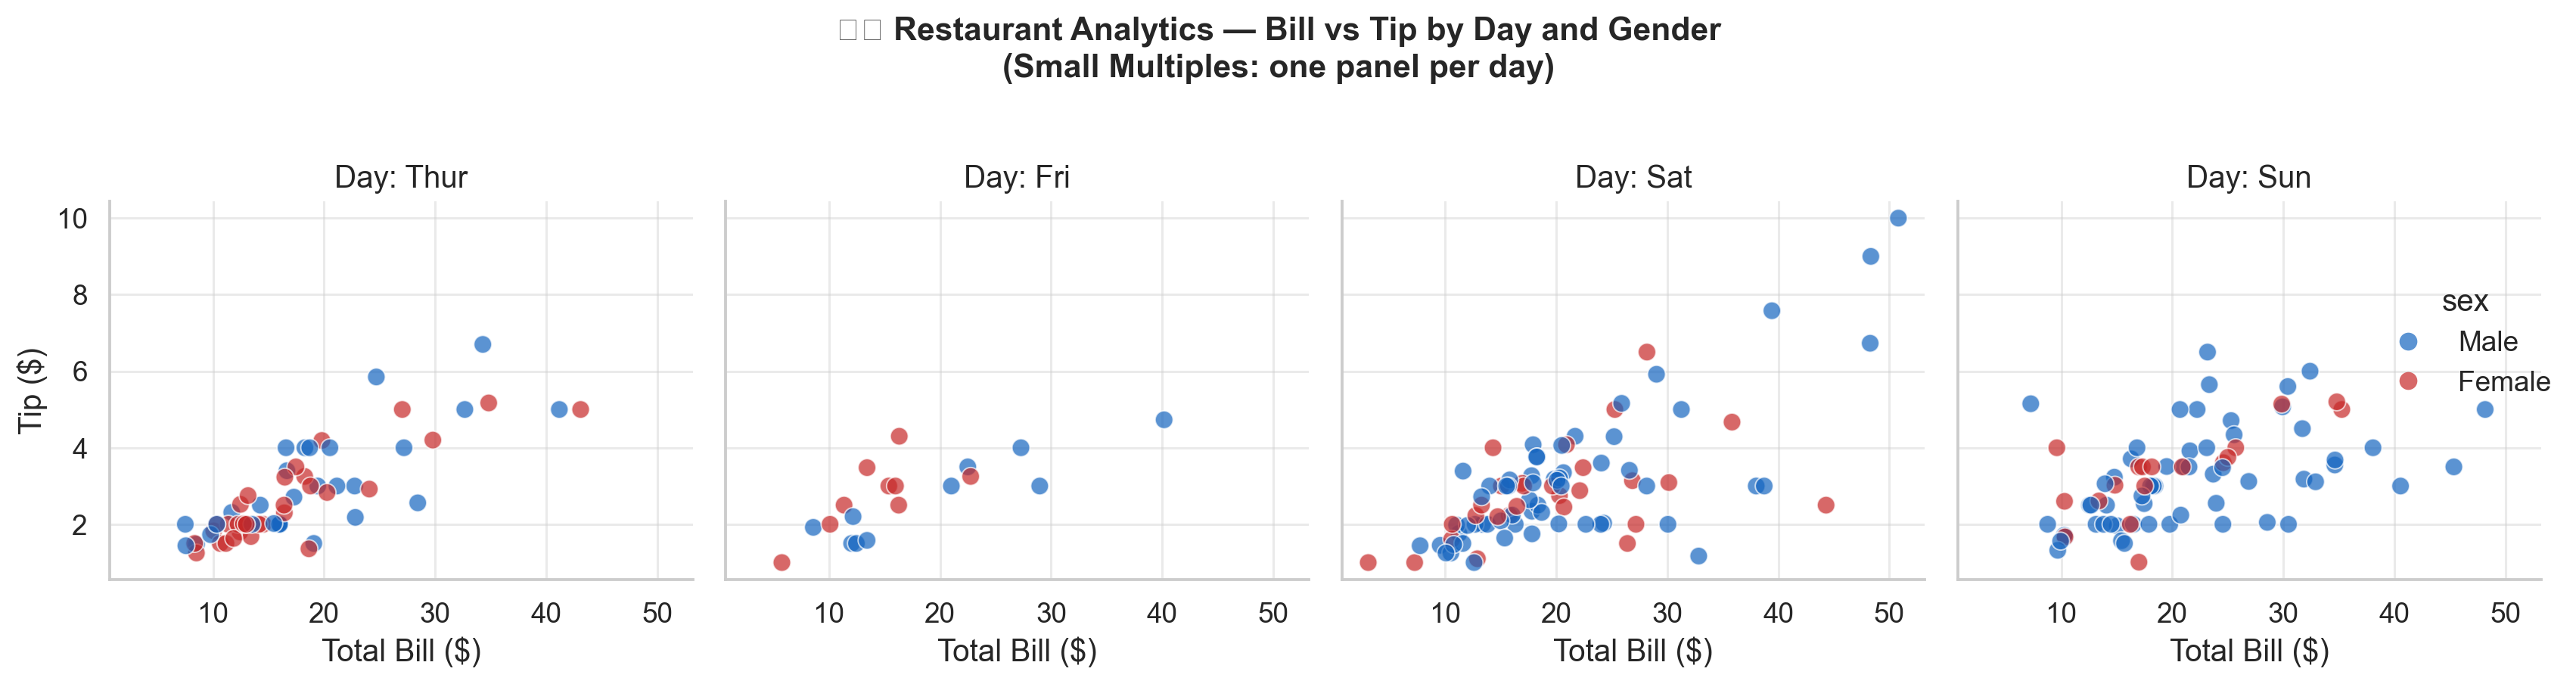

📊 INSIGHT: The positive bill→tip relationship holds consistently across ALL days.
   Sunday has more high-value outlier tables (top-right dots).
   Gender doesn't significantly split the tipping pattern on any day.


In [11]:
# 🟡 Intermediate | relplot with col= — small multiples pattern
# Business Problem: Does the bill-tip relationship hold for ALL days,
# or does it break down on certain days? Check one panel per day.

g = sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='sex',
    col='day',                     # One panel per day ← the key parameter
    col_order=['Thur', 'Fri', 'Sat', 'Sun'],
    palette={'Male': '#1565C0', 'Female': '#C62828'},
    kind='scatter',
    alpha=0.7,
    s=60,
    height=4,
    aspect=0.9
)

g.set_axis_labels('Total Bill ($)', 'Tip ($)')
g.set_titles(col_template='Day: {col_name}')
g.figure.suptitle(
    '🍽️ Restaurant Analytics — Bill vs Tip by Day and Gender\n'
    '(Small Multiples: one panel per day)',
    fontsize=14, fontweight='bold', y=1.03
)

plt.tight_layout()
plt.show()

print("📊 INSIGHT: The positive bill→tip relationship holds consistently across ALL days.")
print("   Sunday has more high-value outlier tables (top-right dots).")
print("   Gender doesn't significantly split the tipping pattern on any day.")

### 📋 Output Preview — Small Multiples
```
4 panels side by side (Thursday | Friday | Saturday | Sunday)
Each panel: scatter of total_bill vs tip, colored by sex
All panels share the same axes scale for fair comparison
```
> 🎯 **Interview Q:** *"What's the difference between relplot(col='day') and using hue='day' in scatterplot?"*
> → `hue='day'` overlays all days in ONE plot with different colors (gets cluttered with 4+ groups).
> → `col='day'` gives each day its OWN panel — much easier to compare patterns individually.

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3437197222.py:38: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3437197222.py:38: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


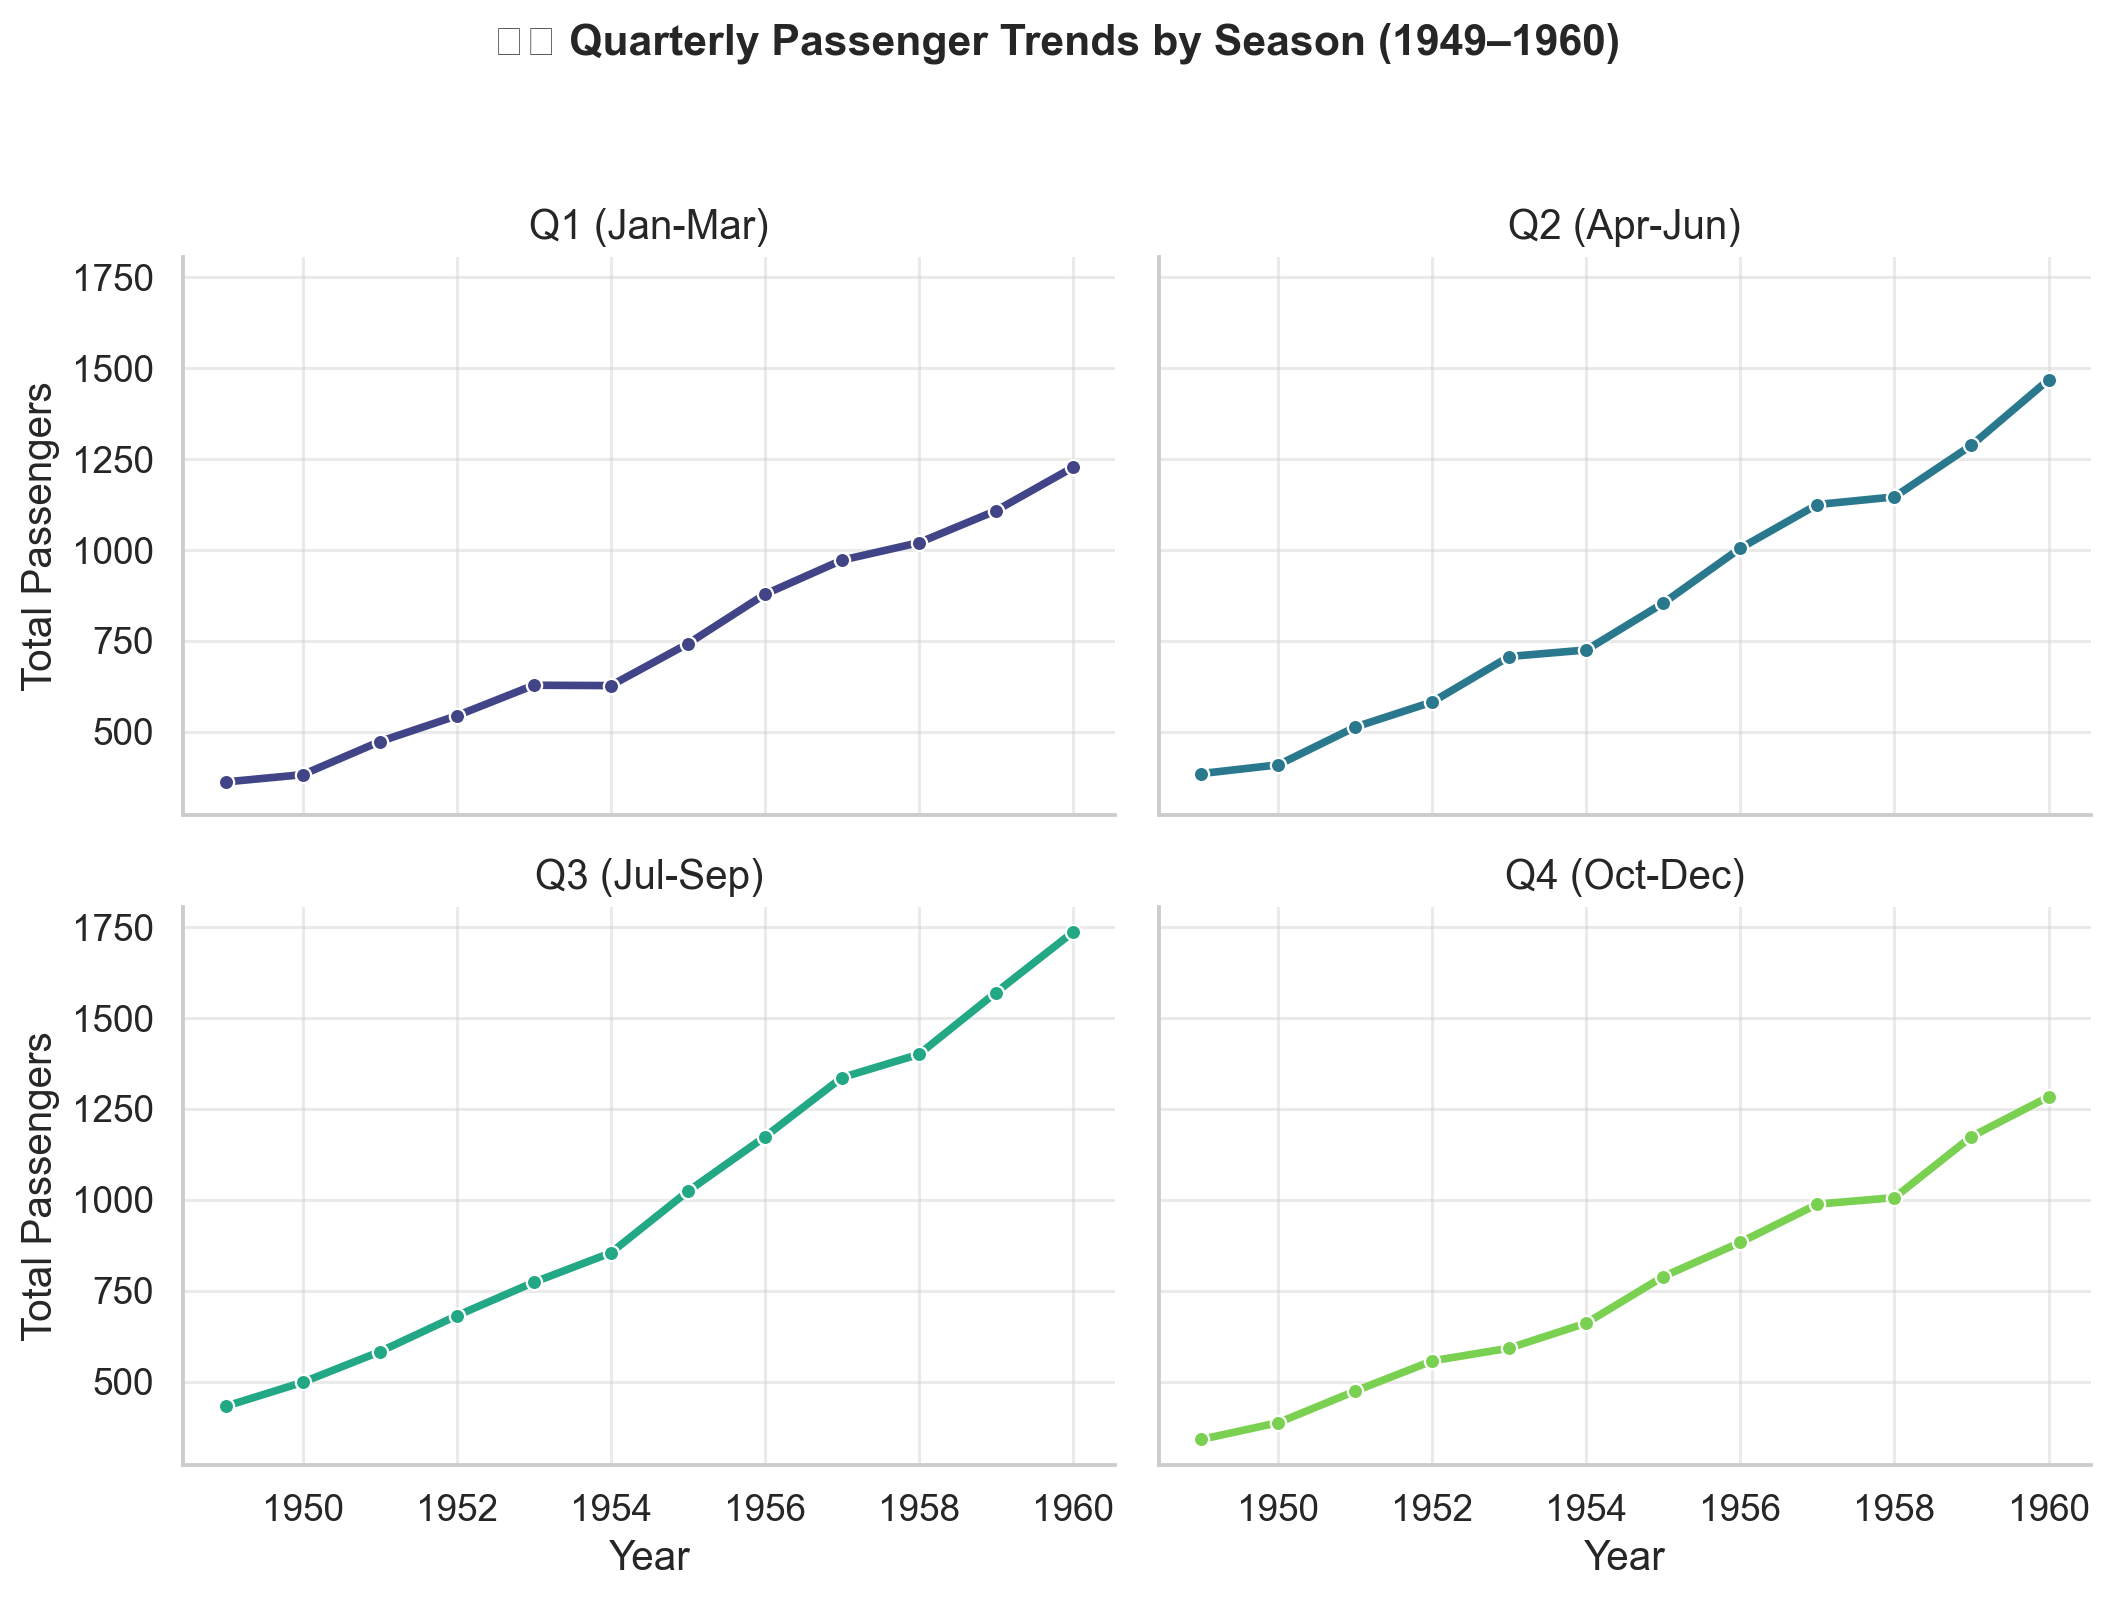

📊 INSIGHT: Q3 (Jul–Sep) consistently has the highest passenger volume — summer peak.
   All quarters show the same upward trend — industry-wide growth, not seasonal.


In [12]:
# 🟡 Intermediate | relplot kind='line' — faceted time series
# Business Problem: How does passenger growth compare across seasons?
# Compare monthly trends for each quarter of the year.

# Engineer quarter column with Pandas
flights['quarter'] = pd.cut(
    flights['month'].map({'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                          'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}),
    bins=[0, 3, 6, 9, 12],
    labels=['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
)

g = sns.relplot(
    data=flights,
    x='year',
    y='passengers',
    hue='quarter',
    col='quarter',              # One panel per quarter
    col_wrap=2,                 # 2 columns (2×2 grid)
    kind='line',
    estimator='sum',
    errorbar=None,
    palette='viridis',
    linewidth=2.5,
    marker='o',
    markersize=5,
    height=3.5,
    aspect=1.4,
    legend=False
)

g.set_axis_labels('Year', 'Total Passengers')
g.set_titles(col_template='{col_name}')
g.figure.suptitle(
    '✈️ Quarterly Passenger Trends by Season (1949–1960)',
    fontsize=14, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.show()

print("📊 INSIGHT: Q3 (Jul–Sep) consistently has the highest passenger volume — summer peak.")
print("   All quarters show the same upward trend — industry-wide growth, not seasonal.")

---

<a id='regplot'></a>
## 6. `regplot` — Regression Line with Confidence Intervals

### 🧠 Intuition

`regplot` does three things simultaneously:
1. **Scatter plot** — shows the raw data points
2. **Regression line** — the best-fit line through the data
3. **Confidence band** — shows uncertainty around the regression estimate

**Why this matters in interviews:** `regplot` is the visual confirmation of **linear regression** — something every Data Science fresher must understand.

### 📌 Syntax & Parameters
```python
sns.regplot(
    data     = df,
    x        = 'num_col',
    y        = 'num_col',
    ci       = 95,           # Confidence interval width (95 = default)
    scatter  = True,         # Show scatter points
    fit_reg  = True,         # Show regression line (set False to hide)
    order    = 1,            # Polynomial degree: 1=linear, 2=quadratic
    lowess   = False,        # True → LOWESS non-parametric smoother
    robust   = False,        # True → Robust regression (resistant to outliers)
    scatter_kws = {'alpha': 0.5, 's': 40},      # Scatter styling
    line_kws    = {'color': 'red', 'lw': 2},    # Line styling
    ax       = ax,           # AXES-LEVEL — accepts ax=
)
```

### 🔑 linear vs LOWESS — The Key Choice
| Method | Assumes | Best For |
|--------|---------|---------|
| `fit_reg=True, lowess=False` | Linear relationship | When scatter shows a straight-line pattern |
| `lowess=True` | NO assumption about shape | Non-linear or unknown relationship |
| `order=2` | Quadratic (U-shaped) | Curved but systematic patterns |

> 💡 **Rule of thumb for freshers:** Always try `lowess=True` first in EDA to see the TRUE shape, then decide if linear is appropriate.

In [ ]:
# 🟢 Basic | regplot — the core regression visualization
# Business Problem: Can we predict tip amount from total bill?
# This is the simplest form of regression analysis — fresher must-know.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Linear regression (default) ──
sns.regplot(
    data=tips,
    x='total_bill',
    y='tip',
    ci=95,
    scatter_kws={'alpha': 0.55, 's': 40, 'color': '#1565C0'},
    line_kws={'color': '#E53935', 'linewidth': 2.5},
    ax=axes[0]
)
axes[0].set_title(
    'Linear Regression: Total Bill → Tip\n'
    '(Red line = best fit | Shaded = 95% CI)',
    fontweight='bold', fontsize=11
)
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip Amount ($)')

# Add R² annotation
corr = tips['total_bill'].corr(tips['tip'])
r_sq = corr ** 2
axes[0].annotate(
    f'R² = {r_sq:.3f}\n(Model explains {r_sq*100:.1f}% of tip variance)',
    xy=(35, 2), fontsize=10, color='#c62828',
    bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.8)
)

# ── Right: Linear vs LOWESS comparison ──
sns.regplot(
    data=mpg,
    x='horsepower',
    y='mpg',
    ci=95,
    scatter_kws={'alpha': 0.30, 's': 25, 'color': '#888'},
    line_kws={'color': '#1565C0', 'linewidth': 2.5, 'label': 'Linear fit'},
    ax=axes[1]
)
sns.regplot(
    data=mpg,
    x='horsepower',
    y='mpg',
    ci=None,                   # No CI for LOWESS (computationally expensive)
    scatter=False,             # Don't replot points
    lowess=True,               # LOWESS: non-parametric, follows actual shape
    line_kws={'color': '#E53935', 'linewidth': 2.5,
              'linestyle': '--', 'label': 'LOWESS (actual shape)'},
    ax=axes[1]
)
axes[1].set_title(
    'Horsepower vs MPG — Linear vs LOWESS\n'
    '(Blue=Linear assumes straight line | Red=LOWESS follows real shape)',
    fontweight='bold', fontsize=11
)
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Miles Per Gallon (mpg)')
axes[1].legend(fontsize=10)

fig.suptitle('📈 Regression Analysis — Linear Fit & LOWESS Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"📊 INSIGHT (Left): R² = {r_sq:.3f} — the model explains {r_sq*100:.1f}% of tip variance.")
print(f"   The remaining {(1-r_sq)*100:.1f}% is due to other factors (generosity, service, etc.)")
print(f"\n📊 INSIGHT (Right): The LINEAR line underestimates mpg at low horsepower")
print(f"   and overestimates at high horsepower. LOWESS reveals a CURVED relationship.")
print(f"   → A linear model would be wrong here. Use polynomial or tree-based models.")

### 📋 Output Preview — regplot Key Numbers
```
📊 INSIGHT (Left): R² = 0.457 — the model explains 45.7% of tip variance.
   The remaining 54.3% is due to other factors (generosity, service quality, etc.)

📊 INSIGHT (Right): The LINEAR line is wrong for horsepower→mpg.
   LOWESS reveals a CURVED relationship → use polynomial or tree-based models.
```
> 🎯 **Interview Q:** *"What does R² = 0.457 mean?"*
> → Our linear model using `total_bill` as the predictor **explains 45.7% of the variation** in tip amounts. The rest is unexplained by this single feature.

> 🎯 **Interview Q:** *"When would you use `lowess=True` instead of the default linear fit?"*
> → When you don't want to **assume** a linear relationship. LOWESS reveals the TRUE shape of the relationship without any parametric assumptions.

In [ ]:
# 🔴 Advanced | regplot — polynomial and residual interpretation
# Business Problem: Is the diamond price-to-carat relationship really linear?
# Choosing the right regression order affects model performance significantly.

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sample_diamonds = diamonds.sample(n=1000, random_state=42)

# ── Panel 1: Linear fit (order=1) ──
sns.regplot(
    data=sample_diamonds,
    x='carat', y='price',
    order=1,
    ci=95,
    scatter_kws={'alpha': 0.25, 's': 20, 'color': '#888'},
    line_kws={'color': '#1565C0', 'linewidth': 2.5},
    ax=axes[0]
)
axes[0].set_title('order=1 (Linear)\nPoor fit — underestimates high-carat', fontweight='bold')
axes[0].set_xlabel('Carat')
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Panel 2: Quadratic fit (order=2) ──
sns.regplot(
    data=sample_diamonds,
    x='carat', y='price',
    order=2,                   # Polynomial degree 2
    ci=95,
    scatter_kws={'alpha': 0.25, 's': 20, 'color': '#888'},
    line_kws={'color': '#E53935', 'linewidth': 2.5},
    ax=axes[1]
)
axes[1].set_title('order=2 (Quadratic)\nBetter — captures curve', fontweight='bold')
axes[1].set_xlabel('Carat')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Panel 3: LOWESS — actual shape ──
sns.regplot(
    data=sample_diamonds,
    x='carat', y='price',
    lowess=True,
    ci=None,
    scatter_kws={'alpha': 0.25, 's': 20, 'color': '#888'},
    line_kws={'color': '#2E7D32', 'linewidth': 2.5},
    ax=axes[2]
)
axes[2].set_title('lowess=True (Non-parametric)\nMost honest — no assumptions', fontweight='bold')
axes[2].set_xlabel('Carat')
axes[2].set_ylabel('')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.suptitle('💎 Diamond Analytics — Choosing the Right Regression Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("📊 INSIGHT: Price grows FASTER than linearly with carat size.")
print("   A 2-carat diamond costs much more than 2× a 1-carat diamond.")
print("   The quadratic fit captures this better than linear.")
print("   → For an ML model, consider log(price) or polynomial features.")

---

<a id='lmplot'></a>
## 7. `lmplot` — Faceted Regression (Figure-level)

### 🧠 Intuition

`lmplot` = `regplot` + `FacetGrid`

- **`regplot`** draws ONE regression line on one Axes
- **`lmplot`** draws SEPARATE regression lines per group, with optional faceting

**The key question `lmplot` answers:** *"Does the relationship between X and Y change across different groups?"*

> ⚠️ **Important:** `lmplot` is **figure-level** — it creates its own Figure. Cannot use `ax=`.

In [ ]:
# 🟡 Intermediate | lmplot — separate regression lines per group
# Business Problem: Does the bill→tip relationship differ between
# smokers and non-smokers? Between lunch and dinner?
# This is a key EDA question before building a predictive model.

# ── Plot 1: hue — overlaid regressions ──
g1 = sns.lmplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    palette={'Yes': '#E53935', 'No': '#1E88E5'},
    scatter_kws={'alpha': 0.55, 's': 40},
    line_kws={'linewidth': 2.5},
    ci=95,
    height=5,
    aspect=1.3
)
g1.set_axis_labels('Total Bill ($)', 'Tip Amount ($)')
g1.figure.suptitle(
    '🍽️ lmplot: Bill→Tip Regression by Smoker Status\n'
    '(Parallel lines → similar slope → smoking has little effect on tipping)',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()

print("📊 INSIGHT: Both regression lines have SIMILAR slopes.")
print("   Smoker status does NOT significantly change how tips scale with bill size.")

In [ ]:
# 🟡 Intermediate | lmplot with col= — faceted regressions
# Business Problem: Does horsepower→mpg relationship vary by cylinder count?
# Automotive Analytics — critical for vehicle efficiency modeling.

g2 = sns.lmplot(
    data=mpg,
    x='horsepower',
    y='mpg',
    col='cylinders',
    col_order=[4, 6, 8],        # Only common cylinder counts
    hue='cylinders',
    palette={4: '#43A047', 6: '#FB8C00', 8: '#E53935'},
    scatter_kws={'alpha': 0.50, 's': 30},
    line_kws={'linewidth': 2.2},
    ci=95,
    height=4,
    aspect=1.0
)
g2.set_axis_labels('Horsepower', 'Miles Per Gallon (mpg)')
g2.set_titles(col_template='{col_name} Cylinders')
g2.figure.suptitle(
    '🚗 Automotive Analytics — Horsepower vs MPG by Cylinder Count\n'
    '(Each panel = separate regression for that engine type)',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()

print("📊 INSIGHT: The negative horsepower→mpg slope is consistent across all cylinder counts.")
print("   4-cylinder: high mpg, low HP range | 8-cylinder: low mpg, high HP range.")
print("   The relationship is STEEPER for 4-cylinder engines — they lose efficiency faster.")

---

<a id='hue-style-size'></a>
## 8. Multi-variable Encoding — Hue · Style · Size

### 🧠 Intuition — Visual Encoding Channels

Every visual property of a mark (dot, line) can carry information:

| Channel | Parameter | Data Type | Example |
|---------|-----------|-----------|---------|
| X position | `x=` | Numeric / Ordered | Total bill |
| Y position | `y=` | Numeric | Tip amount |
| Color | `hue=` | Categorical / Numeric | Species, Smoker |
| Shape | `style=` | Categorical | Sex, Diet |
| Size | `size=` | Numeric | Body mass, Party size |

**Rule:** Use at most 3 channels (x, y, hue) for general audiences. Add style/size only when the audience is analytical.

In [ ]:
# 🔴 Advanced | Full multi-variable encoding — production-quality EDA chart
# Business Problem: Summarize ALL key penguin measurements in ONE chart.
# Used in ML EDA to quickly see which features separate classes.

fig, ax = plt.subplots(figsize=(13, 8))

sns.scatterplot(
    data=penguins,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    style='island',            # Island where captured
    size='bill_length_mm',     # Bill length as size
    sizes=(40, 350),
    palette='colorblind',
    alpha=0.80,
    markers={'Torgersen': 'o', 'Biscoe': 's', 'Dream': '^'},
    ax=ax
)

ax.set_title(
    '🐧 Penguin Multi-variable Analysis\n'
    '(Color=Species | Shape=Island | Size=Bill Length)',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Flipper Length (mm)', fontsize=12)
ax.set_ylabel('Body Mass (g)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}g'))
ax.legend(
    title='Species / Island / Bill Length',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8.5,
    title_fontsize=9.5
)

plt.tight_layout()
plt.show()

print("📊 INSIGHT: Gentoo (squares, Biscoe Island) cluster in top-right — heaviest, longest flippers.")
print("   Adelie found on all 3 islands; Chinstrap only on Dream Island.")
print("   Flipper length + body mass together almost perfectly separate Gentoo from the rest.")
print("   → These two features alone would give a high-accuracy classifier for Gentoo species.")

---

<a id='ci-anatomy'></a>
## 9. Confidence Interval Anatomy — What CIs Actually Mean

### 🧠 Why This Matters for Freshers

**95% CI** appears on `barplot`, `lineplot`, and `regplot` — and interviewers ask about it constantly.

### The Correct Explanation
> A **95% Confidence Interval** means: *"If we repeated this study 100 times with different random samples, 95 of those intervals would contain the true population mean."*

**What it is NOT:**
- ❌ "95% probability the true mean is in this interval" (frequentist CI ≠ probability statement about fixed true mean)
- ❌ "95% of the data falls in this range" (that's a prediction interval)

### 🔑 Practical Rules for Interviews
| Observation | Interpretation |
|-------------|----------------|
| Two CIs **don't overlap** | Groups are likely significantly different |
| Two CIs **do overlap** | Cannot conclude significant difference |
| CI gets **wider** | Sample size is smaller OR variance is higher |
| CI gets **narrower** | More data OR less variance |

In [ ]:
# 🟡 Intermediate | CI visualization — understanding width and overlap
# Business Problem: Which days show significantly different tip amounts?
# Understanding CI overlap helps make data-driven staffing decisions.

day_order = ['Thur', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: CI comparison across days ──
sns.barplot(
    data=tips,
    x='day',
    y='tip',
    order=day_order,
    hue='day',
    palette='Set2',
    estimator='mean',
    errorbar=('ci', 95),
    capsize=0.12,
    errwidth=2,
    legend=False,
    ax=axes[0]
)
axes[0].set_title(
    'Average Tip by Day — 95% Confidence Intervals\n'
    '(Overlapping CIs → days NOT significantly different)',
    fontweight='bold', fontsize=11
)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Average Tip ($)')

# Annotate with sample sizes
day_counts = tips.groupby('day')['tip'].count().reindex(day_order)
axes[0].text(0, 0.3, f'n={day_counts["Thur"]}', ha='center', fontsize=9, color='#555')
axes[0].text(1, 0.3, f'n={day_counts["Fri"]}',  ha='center', fontsize=9, color='#555')
axes[0].text(2, 0.3, f'n={day_counts["Sat"]}',  ha='center', fontsize=9, color='#555')
axes[0].text(3, 0.3, f'n={day_counts["Sun"]}',  ha='center', fontsize=9, color='#555')

# ── Right: Same data with sd vs ci comparison ──
sns.lineplot(
    data=tips,
    x='day',
    y='tip',
    hue='sex',
    estimator='mean',
    errorbar=('ci', 95),
    palette={'Male': '#1565C0', 'Female': '#C62828'},
    linewidth=2.5,
    markers=True,
    markersize=9,
    order=day_order,
    ax=axes[1]
)
axes[1].set_title(
    'Tip Trend by Day and Gender\n'
    '(Bands = 95% CI | Do male/female CIs overlap?)',
    fontweight='bold', fontsize=11
)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Tip ($)')
axes[1].legend(title='Gender', fontsize=10)

fig.suptitle('🎯 Confidence Interval Interpretation — Restaurant Analytics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("📊 INSIGHT: Friday has the WIDEST CI (n=19, smallest sample) — least reliable estimate.")
print("   Saturday and Sunday CIs overlap heavily → no significant difference between those days.")
print("   Male/Female CI bands overlap on most days → gender doesn't significantly affect tip.")

---

<a id='anscombe'></a>
## 10. Anscombe's Quartet — Why You MUST Always Visualize

### 🧠 The Most Important Lesson in Data Science

In 1973, statistician Francis Anscombe created four datasets (I, II, III, IV) that are **statistically identical**:
- Same mean of x and y
- Same variance of x and y  
- Same correlation coefficient
- Same regression line

Yet when plotted, they look **completely different**.

This is why **summary statistics alone are never enough** — you must always visualize.

> 🎯 **This is one of the most famous examples in data science.** Knowing it will impress any interviewer.

In [13]:
# 🔴 Advanced | Anscombe's Quartet — the most famous visualization example
# Why: Proves that summary statistics can be identical while data is wildly different.
# Every Data Scientist must know this — it's the strongest argument for EDA.

# ── Show that summary stats are identical ──
print("=== Anscombe's Quartet — Summary Statistics ===")
print()
stats_df = anscombe.groupby('dataset')['x', 'y'].agg(['mean', 'var']).round(3)
print(stats_df.to_string())

print()
corrs = anscombe.groupby('dataset').apply(
    lambda g: g['x'].corr(g['y'])
).round(3)
print("Correlation (x, y) per dataset:")
print(corrs.to_string())
print()
print("⬆️  All nearly IDENTICAL statistics — yet the plots below look nothing alike!")
print()

# ── The reveal: 4 completely different plots ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Dataset I — linear relationship with noise
ds1 = anscombe[anscombe['dataset'] == 'I']
sns.regplot(data=ds1, x='x', y='y', ci=95,
            scatter_kws={'color': '#1565C0', 'alpha': 0.8, 's': 60},
            line_kws={'color': '#E53935', 'lw': 2},
            ax=axes[0, 0])
axes[0, 0].set_title('Dataset I — Linear (ideal case)\n✅ Linear regression is appropriate',
                      fontweight='bold', color='#2e7d32')

# Dataset II — curved relationship
ds2 = anscombe[anscombe['dataset'] == 'II']
sns.regplot(data=ds2, x='x', y='y', ci=95,
            scatter_kws={'color': '#6A1B9A', 'alpha': 0.8, 's': 60},
            line_kws={'color': '#E53935', 'lw': 2},
            ax=axes[0, 1])
axes[0, 1].set_title('Dataset II — Curved relationship\n❌ Linear line MISSES the curve',
                      fontweight='bold', color='#c62828')

# Dataset III — one outlier distorts everything
ds3 = anscombe[anscombe['dataset'] == 'III']
sns.regplot(data=ds3, x='x', y='y', ci=95,
            scatter_kws={'color': '#E65100', 'alpha': 0.8, 's': 60},
            line_kws={'color': '#E53935', 'lw': 2},
            ax=axes[1, 0])
axes[1, 0].set_title('Dataset III — One outlier ruins the model\n❌ Remove outlier first!',
                      fontweight='bold', color='#c62828')

# Dataset IV — all x same except one point
ds4 = anscombe[anscombe['dataset'] == 'IV']
sns.regplot(data=ds4, x='x', y='y', ci=95,
            scatter_kws={'color': '#1B5E20', 'alpha': 0.8, 's': 60},
            line_kws={'color': '#E53935', 'lw': 2},
            ax=axes[1, 1])
axes[1, 1].set_title("Dataset IV — Leverage point\n❌ One outlier controls the entire line",
                      fontweight='bold', color='#c62828')

fig.suptitle(
    "Anscombe's Quartet — 4 Datasets with IDENTICAL Statistics, COMPLETELY Different Shapes\n"
    "This is WHY exploratory visualization is not optional.",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

=== Anscombe's Quartet — Summary Statistics ===



ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

### 📋 Output Preview — Anscombe's Quartet Key Numbers
```
All 4 datasets have:
  Mean of x ≈ 9.0    |  Mean of y ≈ 7.5
  Var of x  ≈ 11.0   |  Var of y  ≈ 4.12
  Correlation ≈ 0.816
  Same regression line: y = 3 + 0.5x

Yet the plots are RADICALLY different.
```
> 🎯 **Interview Answer:** *"Why is EDA important even if you already have summary statistics?"*
> → **Anscombe's Quartet** proves that datasets with identical means, variances, and correlations can have completely different structures. Summary statistics can be dangerously misleading. **Always visualize before modeling.**

---

<a id='dashboard'></a>
## 11. Business Dashboard — Putting It All Together

/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3774656496.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend(title='Origin', fontsize=9)
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3774656496.py:95: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3774656496.py:95: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3774656496.py:95: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pk/b1n6lmf944b3fm6882d66scw0000gn/T/ipykernel_8907/3774656496.py:95: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Arial.
  

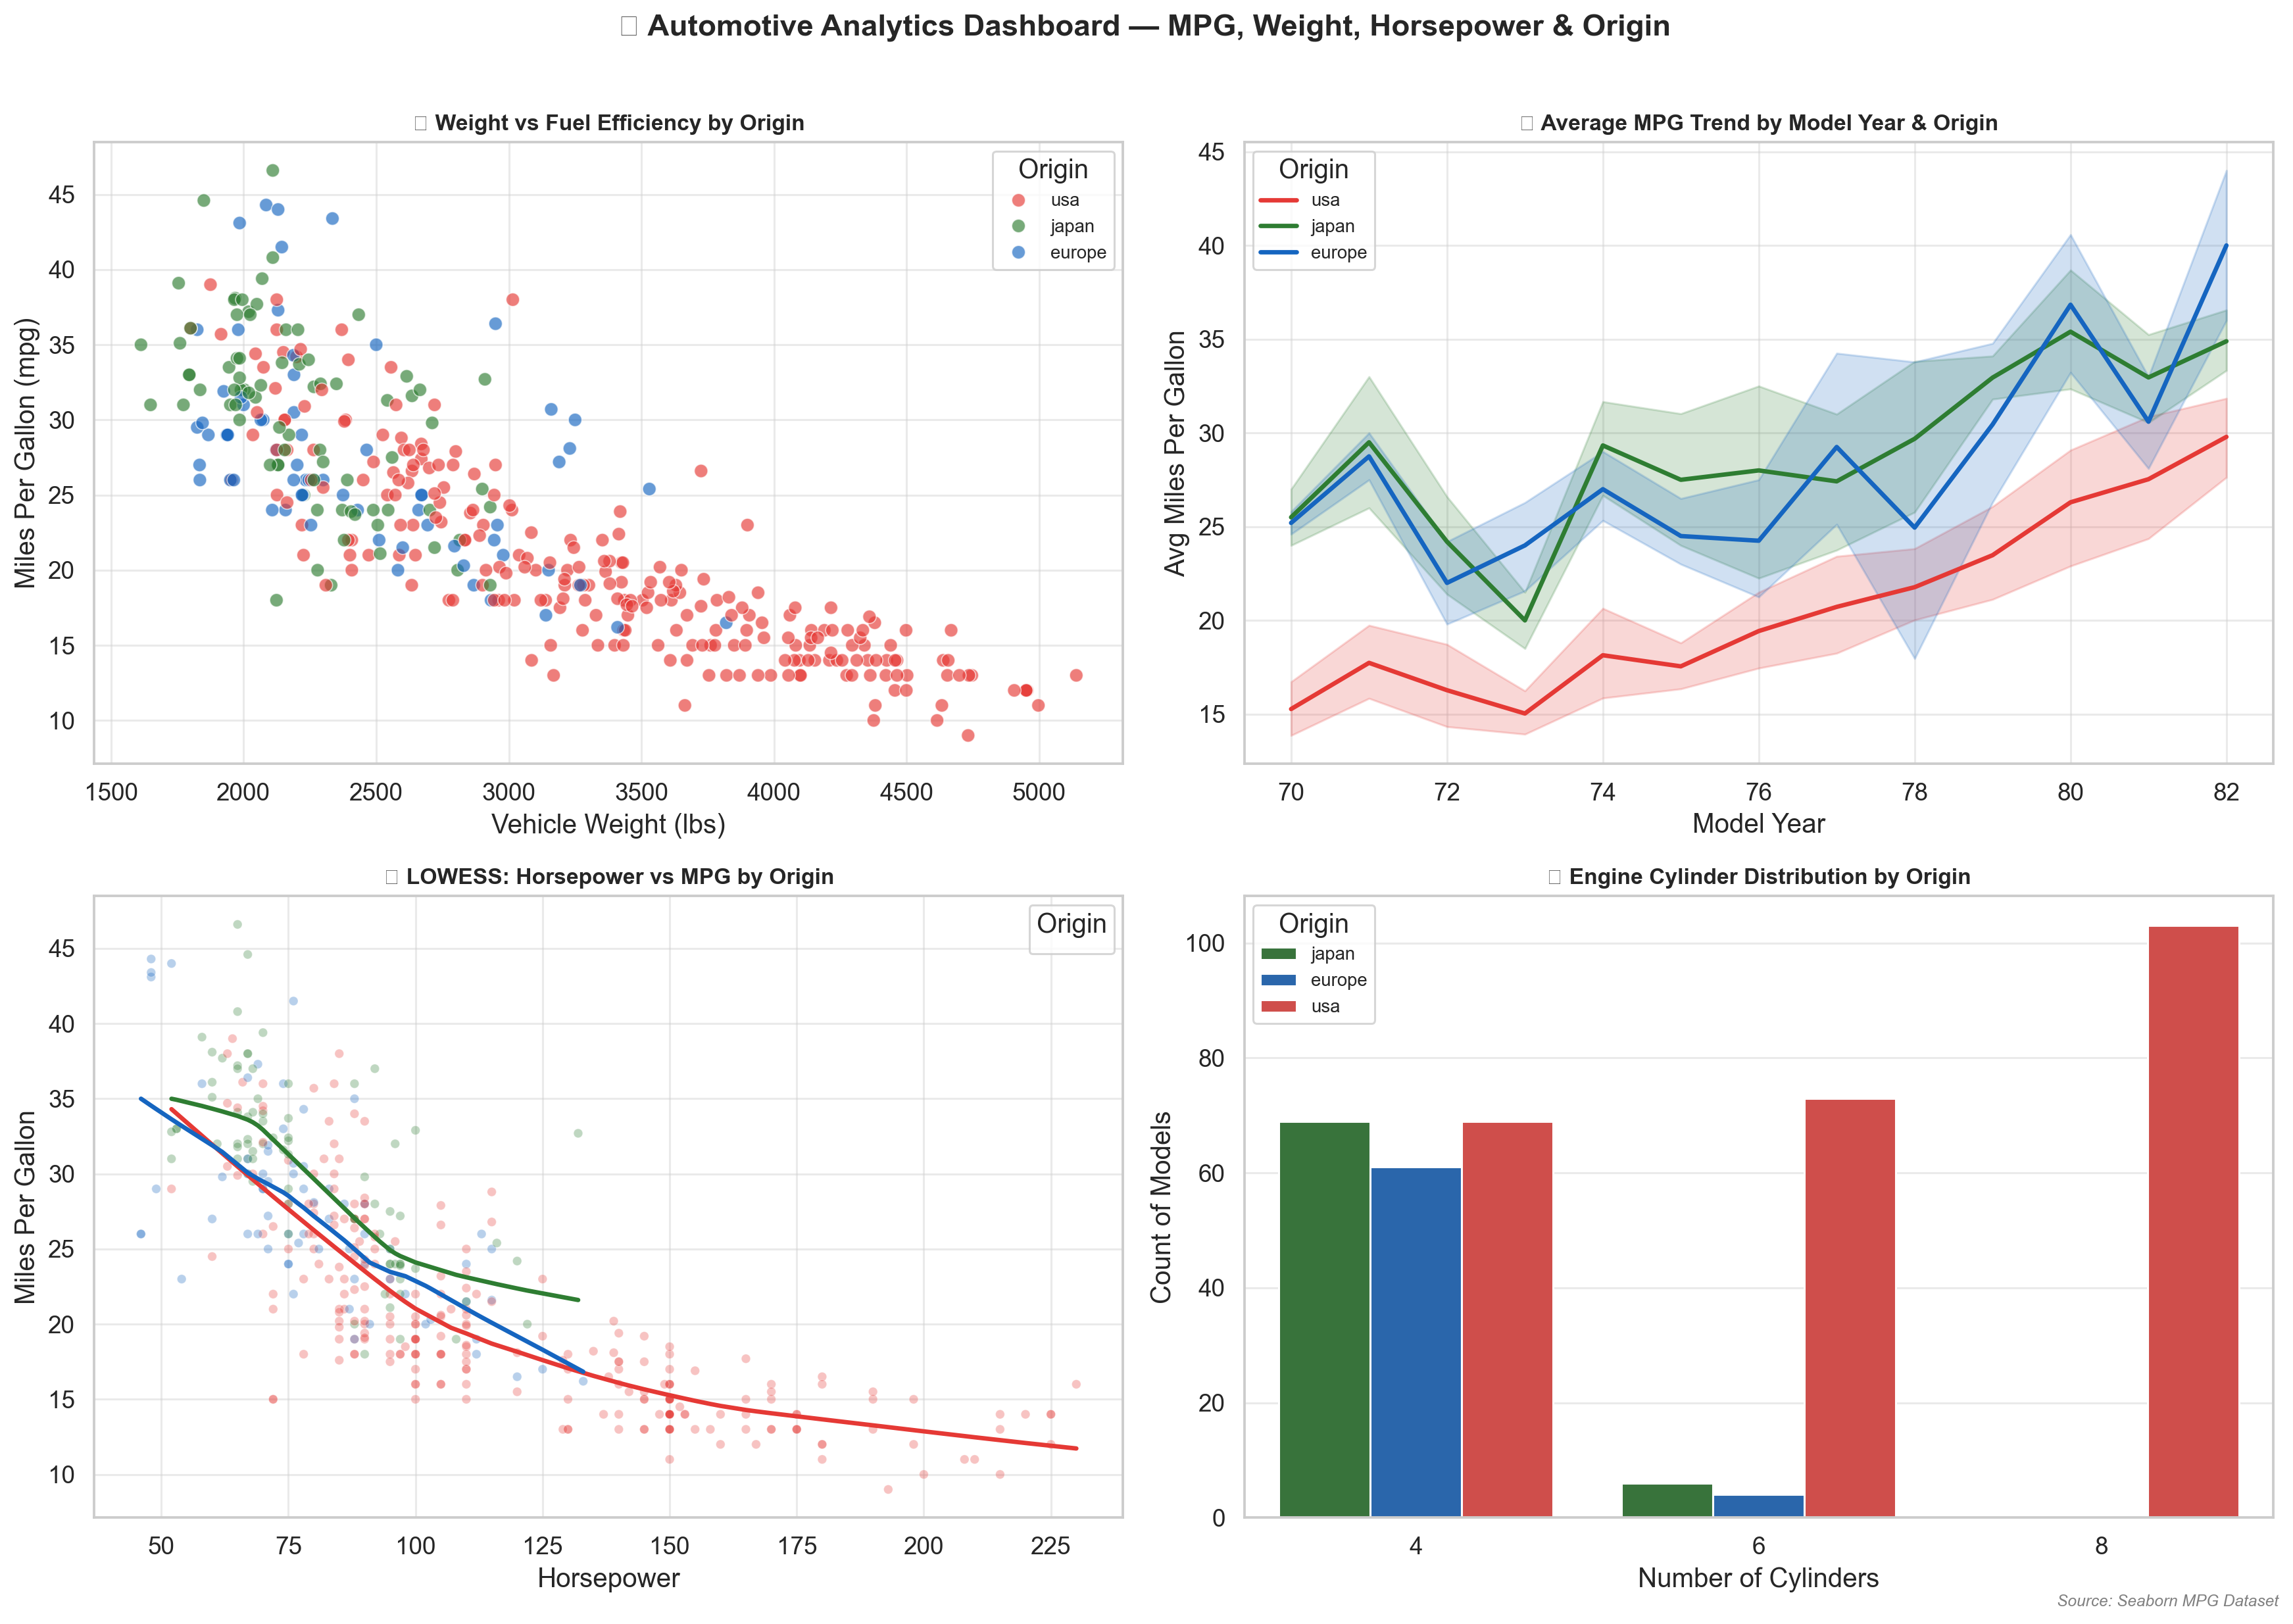

✅ Dashboard saved: outputs/automotive_dashboard.png

📊 KEY INSIGHTS:
   1. Heavier vehicles consistently get worse mpg — strong negative correlation
   2. MPG improved significantly post-1975 for all origins — likely fuel crisis response
   3. Japanese vehicles lead in efficiency at all horsepower levels
   4. USA dominated 8-cylinder (low efficiency) engines; Japan focused on 4-cylinder


In [14]:
# 🔴 Advanced | Complete Relational Analytics Dashboard
# Business Goal: Automotive industry report answering 4 key questions:
#   1. How does weight relate to fuel efficiency?  (scatterplot)
#   2. How has average MPG changed over model years? (lineplot)
#   3. Does horsepower predict MPG differently by origin? (regplot multi)
#   4. How do cylinders distribute by origin? (countplot — from NB2)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Panel 1: Weight vs MPG scatter ──
sns.scatterplot(
    data=mpg,
    x='weight',
    y='mpg',
    hue='origin',
    palette={'usa': '#E53935', 'europe': '#1565C0', 'japan': '#2E7D32'},
    alpha=0.65,
    s=45,
    ax=axes[0, 0]
)
axes[0, 0].set_title('① Weight vs Fuel Efficiency by Origin', fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('Vehicle Weight (lbs)')
axes[0, 0].set_ylabel('Miles Per Gallon (mpg)')
axes[0, 0].legend(title='Origin', fontsize=9)

# ── Panel 2: MPG trend over model years ──
sns.lineplot(
    data=mpg,
    x='model_year',
    y='mpg',
    hue='origin',
    estimator='mean',
    errorbar=('ci', 95),
    palette={'usa': '#E53935', 'europe': '#1565C0', 'japan': '#2E7D32'},
    linewidth=2.2,
    markers=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title('② Average MPG Trend by Model Year & Origin', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Model Year')
axes[0, 1].set_ylabel('Avg Miles Per Gallon')
axes[0, 1].legend(title='Origin', fontsize=9)

# ── Panel 3: regplot — HP vs MPG by origin (overlaid) ──
sns.regplot(
    data=mpg[mpg['origin'] == 'usa'],
    x='horsepower', y='mpg', ci=None, scatter=False, lowess=True,
    line_kws={'color': '#E53935', 'lw': 2.2, 'label': 'USA'},
    ax=axes[1, 0]
)
sns.regplot(
    data=mpg[mpg['origin'] == 'europe'],
    x='horsepower', y='mpg', ci=None, scatter=False, lowess=True,
    line_kws={'color': '#1565C0', 'lw': 2.2, 'label': 'Europe'},
    ax=axes[1, 0]
)
sns.regplot(
    data=mpg[mpg['origin'] == 'japan'],
    x='horsepower', y='mpg', ci=None, scatter=False, lowess=True,
    line_kws={'color': '#2E7D32', 'lw': 2.2, 'label': 'Japan'},
    ax=axes[1, 0]
)
sns.scatterplot(
    data=mpg, x='horsepower', y='mpg',
    hue='origin', palette={'usa': '#E53935', 'europe': '#1565C0', 'japan': '#2E7D32'},
    alpha=0.3, s=20, legend=False, ax=axes[1, 0]
)
axes[1, 0].set_title('③ LOWESS: Horsepower vs MPG by Origin', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Horsepower')
axes[1, 0].set_ylabel('Miles Per Gallon')
axes[1, 0].legend(title='Origin', fontsize=9)

# ── Panel 4: Cylinder distribution by origin ──
cylinder_order = [4, 6, 8]
sns.countplot(
    data=mpg[mpg['cylinders'].isin([4, 6, 8])],
    x='cylinders',
    hue='origin',
    order=cylinder_order,
    palette={'usa': '#E53935', 'europe': '#1565C0', 'japan': '#2E7D32'},
    ax=axes[1, 1]
)
axes[1, 1].set_title('④ Engine Cylinder Distribution by Origin', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Number of Cylinders')
axes[1, 1].set_ylabel('Count of Models')
axes[1, 1].legend(title='Origin', fontsize=9)

fig.suptitle(
    '🚗 Automotive Analytics Dashboard — MPG, Weight, Horsepower & Origin',
    fontsize=15, fontweight='bold', y=1.01
)
fig.text(0.99, 0.01, 'Source: Seaborn MPG Dataset', ha='right',
         fontsize=8, color='gray', style='italic')

plt.tight_layout()
fig.savefig('outputs/automotive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Dashboard saved: outputs/automotive_dashboard.png")
print()
print("📊 KEY INSIGHTS:")
print("   1. Heavier vehicles consistently get worse mpg — strong negative correlation")
print("   2. MPG improved significantly post-1975 for all origins — likely fuel crisis response")
print("   3. Japanese vehicles lead in efficiency at all horsepower levels")
print("   4. USA dominated 8-cylinder (low efficiency) engines; Japan focused on 4-cylinder")

---

<a id='best-practices'></a>
## 12. Best Practices

| Category | Best Practice |
|----------|--------------|
| **scatterplot** | Always set `alpha` < 1 for any dataset with n > 100 |
| **scatterplot** | Use `hue` for 2–4 groups max — beyond that, use `relplot(col=)` |
| **lineplot** | Use `errorbar=None` when using `estimator='sum'` (CI on sums is meaningless) |
| **lineplot** | Use `style=` + `markers=True` for accessibility (don't rely on color alone) |
| **relplot** | Use `col_wrap=` to prevent too many panels in one row |
| **regplot** | Always try `lowess=True` first to check if linear is appropriate |
| **regplot** | Report R² alongside the plot — don't show regression without explanation |
| **lmplot** | Use `hue=` to check if the regression slope changes across groups |
| **General** | Use `scatter_kws={'alpha': 0.5}` and `line_kws={'linewidth': 2}` for clean styling |
| **General** | For n > 5000, use `kdeplot(2D)` instead of scatterplot — much cleaner |
| **Axes-level** | Always pass `ax=` when embedding in subplots |
| **Figure-level** | Never pass `ax=` to `relplot` or `lmplot` — they manage their own figure |

---

<a id='common-mistakes'></a>
## 13. Common Mistakes

| Mistake | Problem | Fix |
|---------|---------|-----|
| Using `relplot` inside `plt.subplots()` | Layout conflict — figure created twice | Use axes-level `scatterplot` with `ax=` inside subplots |
| Not setting `alpha` with large datasets | Black overplotted blob — structure invisible | Set `alpha=0.2–0.4` for n > 500 |
| Using `lineplot` for categorical x without `order=` | Lines connect in wrong sequence | Always pass `order=` for categorical x |
| Reporting regression without R² | "A line" means nothing without model quality | Compute and annotate R² = corr² |
| Using linear regression on clearly curved data | Model is wrong → predictions are wrong | Check with `lowess=True` first |
| Confusing `size=` with `s=` | `size=` maps a column; `s=` sets fixed pixel size | Know which to use |
| Passing `ax=` to `lmplot` or `relplot` | TypeError — figure-level has no `ax=` | Use axes-level equivalent instead |
| Not filtering extreme outliers before regplot | One outlier can tilt the entire line | Use `.quantile()` to cap before plotting |

---

<a id='interview-notes'></a>
## 14. 🎤 Interview Notes

---

**Q: What is the difference between `scatterplot` and `relplot` in Seaborn?**
> *"`scatterplot` is axes-level — it returns a Matplotlib Axes object and accepts `ax=`, making it embeddable in any subplot layout. `relplot` is figure-level — it creates its own Figure and returns a FacetGrid, giving you automatic `col=` and `row=` faceting. Use `scatterplot` for custom dashboards, `relplot` for quick small-multiple exploration."*

---

**Q: What does `lowess=True` do in `regplot`?**
> *"LOWESS (Locally Weighted Scatterplot Smoothing) fits a non-parametric curve that follows the actual shape of the data without assuming linearity. It's the best first step before choosing a model — if LOWESS looks linear, you can use linear regression. If it curves, you need polynomial or non-linear models."*

---

**Q: Why would you use `style=` in addition to `hue=` in a scatterplot?**
> *"To encode an additional categorical variable using marker shapes. More importantly, `style=` makes the chart accessible to colorblind users — they can distinguish groups by shape even if they can't distinguish colors. It's a best practice for public-facing visualizations."*

---

**Q: What does R² mean?**
> *"R-squared is the proportion of variance in the target variable (Y) explained by our predictor (X) through the regression line. R² = 0.45 means our model explains 45% of the variation in Y. The remaining 55% is unexplained — due to other variables, noise, or a non-linear relationship."*

---

**Q: What is Anscombe's Quartet and why does it matter?**
> *"Anscombe's Quartet is four datasets with identical summary statistics (mean, variance, correlation, regression line) that look completely different when plotted. It's the classic demonstration of why EDA and visualization are essential — you cannot rely on statistics alone to understand your data."*

---

<a id='summary'></a>
## 15. Summary & Key Takeaways

| Plot | One-Line Summary |
|------|-----------------|
| `scatterplot` | Relationship between 2 numeric variables; encode up to 3 extra via hue/style/size |
| `lineplot` | Ordered trends (time series) with automatic mean aggregation + CI bands |
| `relplot` | Figure-level wrapper — adds `col=`/`row=` faceting to scatter and line plots |
| `regplot` | Scatter + regression line + CI — always check `lowess=True` first |
| `lmplot` | Figure-level regression — separate lines per group, faceting support |

### 🏆 The Three Non-Negotiable Rules for Relational Plots

```python
# 1. Always check shape with lowess before committing to linear
sns.regplot(data=df, x='x', y='y', lowess=True)

# 2. Always reduce alpha for dense scatterplots
sns.scatterplot(data=df, x='x', y='y', alpha=0.3)  # not alpha=1

# 3. Know which API level you're using — never mix them
# ✅ Axes-level inside subplots:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='x', y='y', ax=ax)

# ✅ Figure-level standalone:
g = sns.relplot(data=df, x='x', y='y', col='cat')
```

---

<a id='practice'></a>
## 16. 📝 Practice Questions

---

### 🟢 Easy (1–5)

**Q1.** Using the `tips` dataset, create a `scatterplot` of `total_bill` (x) vs `tip_pct` (y). Color the points by `time` (Lunch/Dinner). Add a proper title and axis labels with units.

**Q2.** Load the `flights` dataset. Create a `lineplot` showing total passengers per year (`estimator='sum'`, `errorbar=None`). Add hollow circle markers and fill the area under the line.

**Q3.** Using the `mpg` dataset, create a `regplot` of `weight` vs `mpg`. Add a title that includes the R² value (compute with Pandas `.corr()`).

**Q4.** Create a `scatterplot` from the `penguins` dataset with `x='flipper_length_mm'`, `y='body_mass_g'`, `hue='species'`. Use `palette='colorblind'` and `alpha=0.7`.

**Q5.** What is the difference between passing `hue='day'` in `scatterplot` vs `col='day'` in `relplot`? Write both versions for `tips` data (total_bill vs tip) and explain which is cleaner for 4 groups.

---

### 🟡 Medium (6–11)

**Q6.** Create a 1×3 `relplot` (using `col='origin'`) showing horsepower vs mpg from the `mpg` dataset. Each panel should have its own regression line. Use `kind='scatter'` and overlay `regplot` lines manually on the axes.

**Q7.** Using the `exercise` dataset, create a `lineplot` with `hue='diet'` and `style='kind'`. Use `markers=True` and `dashes=True`. Write 2 business insights about heart rate recovery patterns.

**Q8.** Build a 2×2 figure using `plt.subplots()` that shows:
- Panel 1: `scatterplot` of bill vs tip (colored by day)
- Panel 2: `lineplot` of passengers over year (all flights)
- Panel 3: `regplot` of carat vs price (diamonds, sample 500)
- Panel 4: `regplot` with `lowess=True` for the same diamond data

**Q9.** Using the `mpg` dataset, create an `lmplot` with `x='displacement'`, `y='mpg'`, `hue='origin'`, `col='cylinders'` (filter to 4, 6, 8 cylinders only). Write which origin has the steepest improvement in mpg as displacement decreases.

**Q10.** Reproduce Anscombe's Quartet using Seaborn (the `anscombe` dataset). Before plotting, print the mean, variance, and correlation for all 4 datasets to prove they're identical. Then plot 4 `regplot` panels.

**Q11.** Using the `penguins` dataset, create a `scatterplot` with all 5 encoding channels: `x='bill_length_mm'`, `y='bill_depth_mm'`, `hue='species'`, `style='sex'`, `size='body_mass_g'`. Place the legend outside the plot area using `bbox_to_anchor`.

---

### 🔴 Hard (12–15)

**Q12. 🏗️ Build a Correlation Report Dashboard.**
Using the `mpg` dataset, create a 3×3 figure showing `regplot` for every pair of: `mpg`, `horsepower`, `weight`. That's 9 panels (some will be the same pair flipped). In the title of each panel, include the Pearson r value. This is what `pairplot` does internally — build it manually.

**Q13. 🔍 Regression Diagnostics.**
For the `tips` dataset (total_bill → tip):
1. Fit a regression using `regplot` with `ci=95`
2. Compute residuals: `residuals = tip - (slope × total_bill + intercept)` using Pandas only
3. Plot residuals vs fitted values using `scatterplot`
4. Add a horizontal line at y=0
5. Interpret: are residuals randomly scattered or do they show a pattern?

**Q14. 🎨 Faceted Time Series Report.**
Using the `flights` dataset, create a `relplot` with `kind='line'` where:
- `x='month'`, `y='passengers'`
- `col='year'`, `col_wrap=4`
- `estimator='sum'`, `errorbar=None`
- Each panel has a proper title showing the year
- Use `palette='Blues'` with darker color for later years

**Q15. 🏆 Full EDA Report — MPG Dataset.**
Perform a complete relational EDA on the `mpg` dataset answering:
1. What is the strongest numeric predictor of mpg? (compute all correlations with Pandas, then visualize top 3 with `regplot`)
2. Does country of origin significantly moderate any relationship? (use `lmplot` with `hue='origin'`)
3. How has mpg improved over time, and are some origins improving faster? (lineplot)
4. Are there any non-linear relationships that a linear model would miss? (compare linear `regplot` vs `lowess=True`)
Write a final conclusion paragraph as a markdown cell.

---

### 🔥 Predict the Output Challenge

Study this code and answer the questions **before running**:

```python
g = sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    col='day',
    hue='smoker',
    style='sex',
    kind='scatter',
    col_wrap=2,
    height=4,
    aspect=1.1
)
g.set_axis_labels('Total Bill ($)', 'Tip ($)')
plt.show()
```

❓ Questions:
1. How many panels will this figure have? (hint: how many unique days?)
2. What does `col_wrap=2` do to the layout?
3. How many visual encodings are being used? Name them all.
4. Can you add `ax=axes[0]` to this call? Why or why not?
5. What would you change to make this chart more readable for a non-technical manager?

---

<div style="background: linear-gradient(135deg, #0a1628 0%, #1a2744 100%); padding: 30px; border-radius: 12px; text-align: center; margin-top: 40px;">
  <h2 style="color: #90caf9; font-size: 1.8em;">🎉 Notebook 3 Complete!</h2>
  <p style="color: #e0e8ff; font-size: 1.1em;">You can now visualize relationships, trends, and regression — the core of EDA.</p>
  <hr style="border: 1px solid #90caf9; margin: 15px auto; width: 60%;">
  <p style="color: #ccc;">📚 Next: <strong style='color:#e0e8ff'>Notebook 4</strong> — Multivariate Analysis</p>
  <p style="color: #aaa; font-size: 0.9em;">heatmap · correlation matrix · pairplot · jointplot · missing values</p>
</div>